# **Saudi Arabia Used Cars Prediction**
## **Project Title: Used Cars Price Prediction to Optimize Automotive Platform Pricing Strategy**
### **by : Grace Natalie Catherine** <br>

> Data Source: [Saudi Arabia Used Car Dataset](https://www.kaggle.com/datasets/raihanmuhith/saudi-arabia-used-car)
---------------------

**Contents**

1. Business Understanding
2. Data Understanding
3. Data Cleaning, EDA, Data Preprocessing
4. Machine Learning Modelling
5. Analysis
6. Conclusion and Recommendation

In [101]:
# import library for machine learning

# data manipulation & data analysis
import pandas as pd
import numpy as np

# data visualization
import seaborn as sns
import matplotlib.pyplot as plt

# data preprocessing and preparation
from sklearn.model_selection import train_test_split, cross_val_score, KFold, GridSearchCV, RandomizedSearchCV, cross_validate
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler, OneHotEncoder
from category_encoders import OrdinalEncoder, BinaryEncoder

# pipeline and transformer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer

# modelling - regression
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from xgboost import XGBRegressor
from sklearn.compose import TransformedTargetRegressor

# evaluation metrics - regression
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, mean_squared_error, r2_score

# supress warnings
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_colwidth', 2000)

# **1. Business Understanding**

## **Business Context**


The used car market in Saudi Arabia is estimated to be worth USD 9.60 billion in 2024 and is projected to grow to USD 16.80 billion by 2033, according to IMARC Group. Another source, TechSci Research, forecasts the market to grow at a CAGR (Compound Annual Growth Rate) of 9.8% through 2030. Used car transactions are increasingly conducted online; according to Nexdigm, more than 40% of used car transactions in Saudi Arabia are carried out through digital platforms.

Used car marketplaces in Saudi Arabia play an important role for several reasons:

* **For buyers:** They provide quick access to a wide range of used cars options, greater price and used cars condition transparency, a safer purchasing experience, and a more efficient buying process without the need to visit multiple physical dealerships.
* **For sellers:** They expand market reach, accelerate sales, enhance credibility, and simplify inspection, listing, and transaction processes.
* **Other supporting factors:** The Saudi Arabian used car market is large and rapidly growing, consumers increasingly seek efficiency and transparency, digital platform adoption is high, and the complexity of the market increases the need for trusted intermediaries.

The main stakeholders in this business ecosystem are **Business Owners/Management, Buyers, and Sellers**.

Syarah is one of the largest digital used car marketplaces in Saudi Arabia. The company operates as a third-party intermediary between sellers (individuals or dealerships) and buyers. Sellers can list their used cars and set their own prices, while buyers can browse available cars, purchase them online, and benefit from inspection and delivery services.

In addition, Syarah also purchases used cars directly from car owners, conducts inspections and reconditioning, and then resells the used cars. The official Syarah website provides a **"Sell Your Car / Trade-In"** feature, allowing sellers to sell their cars directly to Syarah without publicly listing them on the marketplace.

Syarah generates revenue from two primary sources: **service fees charged through the marketplace and profit margins earned from used cars sales.**

## **Problem Statement**


Despite the significant growth of the used car market in Saudi Arabia and the fact that more than 40% of transactions have shifted to digital platforms, the pricing mechanism on the Syarah platform is still entirely determined by sellers. This approach often leads to a **mismatch between the listed price and the actual market value** of used cars.

Sellers frequently face challenges in determining an appropriate selling price for used cars because used car values depend on numerous factors and specifications. At the same time, buyers often hesitate to proceed with a purchase because they are uncertain whether the listed price reflects a fair market value and are generally seeking the best deal available.

**Pricing is a critical factor** in the success of a used car marketplace. Inaccurate pricing can result in longer selling periods, prolonged negotiations, and lower conversion rates. Furthermore, pricing decisions can directly impact the company's revenue. **If the used car prices are set too high, buyers may lose interest, leading to lower sales volumes and reduced revenue**. Conversely, **if prices are set too low, sellers may receive lower-than-expected returns, while the company may earn smaller profit margins on used cars sales**.

In the long term, **pricing inefficiencies may reduce customer trust, causing both buyers and sellers to gradually leave the platform and ultimately decreasing overall business profitability**.

To remain competitive and improve revenue & profitability, the company requires a data-driven solution in the form of an accurate used car price prediction model to provide optimal price recommendations for sellers and improve the overall quality of transactions on the platform. Sellers only need to enter the used cars' specifications and the system would automatically generate a recommended selling price for the used cars.

Based on this business problem, this analysis aims to answer the following question:

* **How can we build a machine-learning model to accurately predict used-car prices and maximize revenue?**

## **Goals**


The objectives of this analysis are as follows:

* Built a machine learning model to predict used car selling prices based on various vehicle features, enabling the development of an optimal, realistic, and transparent pricing strategy.
* Identify the key factors influencing used-car prices to support stakeholders in defining actionable strategies.

## **Analytical Approach**


The analytics approach for estimating used car prices is by using **predictive analysis**. This analysis uses **regression analysis** as the primary method for accurately predicting used car prices because **the target variable (price) is a continuous numerical variable**.

#### **Key Analytical Approach**

**1. Data Understanding**
* Understand the dataset by identifying variables, checking duplicates, detect incosistent data, outliers and anomalies.

**2. Data Cleaning, EDA, Data Preprocessing**
* **Data cleaning:** Perform data cleaning by handling missing values, duplicate values, inconsistent data, outliers and anomalies.
* **Exploratory Data Analysis (EDA):** Conduct EDA to identify patterns or trends, gain insights, conduct correlation analysis using heatmaps to understand the relationship and significance of each feature with respect to the target variable.
* **Data Preprocessing** : Conduct multicollinearity analysis.
* **Feature Engineering:** Select relevant features for modeling, split the train and test set, apply appropriate scaling and encoding techniques.

**3. Machine Learning Modeling**
* **Model Selection and Training:** Select and train suitable machine learning algorithms for price prediction.
* **Model Evaluation and Hyperparameter Tuning:** Benchmark models and evaluate model performance using appropriate regression metrics then perform hyperparameter tuning to improve prediction accuracy and reduce prediction errors.
* **Model Improvement:** Enhance model performance through feature generation of new informative features from existing features.
* **Final Model Selection:** Select the best-performing model and analyze feature importance to identify the most important factors affecting used cars prices.

**4. Analysis**
* Compare actual prices with predicted prices to evaluate model performance and prediction reliability.
* Conduct a cost-benefit analysis of the model to assess its financial value to the company, as developing a predictive model is only valuable if it provides financial advantages, whether its potential to increase revenue and improve profit margins through more accurate pricing or to reduce cost associated with inefficient pricing decisions.

**5. Conclusion & Recommendations**
* Draw conclusions from the analysis to support price optimization strategies.
* Provide strategic recommendations for business stakeholders based on the findings and model insights.

## **Evaluation Metrics**

In this project, 2 evaluation metrics are used: **MAPE** and **MAE**, with **MAPE serving as the primary evaluation metric**.

* **MAPE (Mean Absolute Percentage Error):** Measures the average percentage difference between predicted values and actual values relative to the actual values.
* **MAE (Mean Absolute Error):** Measures the average absolute difference between predicted values and actual values.

Since the target variable, **car price**, has a relatively large value range and high variability, MAE is useful for measuring the average prediction error in its original unit. Compared to MSE or RMSE, MAE provides a more direct representation of prediction errors and is generally more robust to outliers.

The main reasons for prioritizing **MAPE** in used car price prediction are as follows:

| Aspect                              | Reason for Using MAPE                                                                                                                         |
| ----------------------------------- | --------------------------------------------------------------------------------------------------------------------------------------------- |
| **Interpretability**                | MAPE is expressed as a percentage, making it easier for stakeholders to understand model error without requiring knowledge of the price unit. |
| **Scale Independence**              | MAPE is not affected by the scale of the target variable, making it suitable when the prices of used cars vary significantly.                 |
| **Outlier Handling**                | MAPE is generally more robust and less influenced by extreme values compared to squared-error metrics.                                        |
| **Target Variable Characteristics** | Well-suited for used car price data, where target values are relatively large and exhibit substantial variation.                              |

Although MAE is included as one of the evaluation metrics, it is not used as the primary metric because:

* MAE is not scale-independent, making comparisons across different price ranges less intuitive.
* It can be more difficult for non-technical stakeholders to interpret.
* It tends to be influenced by large absolute values in the target variable.

---

**Why RMSE and MSE Are Not Used as Primary Metrics**

* **RMSE (Root Mean Squared Error):** Highly sensitive to outliers; a single extreme prediction error can disproportionately increase the metric value.
* **MSE (Mean Squared Error):** Squares prediction errors, which places excessive penalties on outliers and may make model performance appear worse than it actually is under normal conditions.

<br>

> Therefore, **MAPE is selected as the primary evaluation metric because it expresses prediction error as a percentage of the actual value, making the results easier to interpret**. It is also more suitable for used cars price prediction, where target values are relatively large and exhibit high variability, **providing greater robustness against the influence of outliers**.


# **2. Data Understanding**

| **Variables**       | **Description**                                      |
|---------------|----------------------------------------------------------|
| Type          | Type of used car.                                        |
| Region        | The sales region in which the used car was offered for sale.  |
| Make          | The brand/company name.                                  |
| Gear_Type     | Gear type/transmission of used car.                       |
| Origin        | Origin of used car.                                       |
| Options       | Feature/equipment completeness of the used car.           |
| Year          | Manufacturing/production year of the used car.            |
| Engine_Size   | The engine size of the used car.                          |
| Mileage       | Mileage of the used car.                                  |
| Negotiable    | True if the price is negotiable (price is 0), otherwise False. |
| Price         | Price of the used car as target variable to be predicted. |

In [102]:
# load dataset

df = pd.read_csv('data_saudi_used_cars.csv')

df

,Type,Region,Make,Gear_Type,Origin,Options,Year,Engine_Size,Mileage,Negotiable,Price
0,Corolla,Abha,Toyota,Manual,Saudi,Standard,2013,1.4,421000,True,0
1,Yukon,Riyadh,GMC,Automatic,Saudi,Full,2014,8.0,80000,False,120000
2,Range Rover,Riyadh,Land Rover,Automatic,Gulf Arabic,Full,2015,5.0,140000,False,260000
3,Optima,Hafar Al-Batin,Kia,Automatic,Saudi,Semi Full,2015,2.4,220000,False,42000
4,FJ,Riyadh,Toyota,Automatic,Saudi,Full,2020,4.0,49000,True,0
...,...,...,...,...,...,...,...,...,...,...,...
5619,X-Trail,Jeddah,Nissan,Automatic,Saudi,Standard,2018,2.5,78794,False,68000
5620,Altima,Jeddah,Nissan,Automatic,Saudi,Semi Full,2020,2.5,58000,True,0
5621,Yukon,Dammam,GMC,Automatic,Saudi,Full,2016,5.3,48000,False,145000
5622,RX,Dammam,Lexus,Automatic,Gulf Arabic,Full,2016,2.5,81000,False,154000


In [103]:
# initial df info

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5624 entries, 0 to 5623
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Type         5624 non-null   object 
 1   Region       5624 non-null   object 
 2   Make         5624 non-null   object 
 3   Gear_Type    5624 non-null   object 
 4   Origin       5624 non-null   object 
 5   Options      5624 non-null   object 
 6   Year         5624 non-null   int64  
 7   Engine_Size  5624 non-null   float64
 8   Mileage      5624 non-null   int64  
 9   Negotiable   5624 non-null   bool   
 10  Price        5624 non-null   int64  
dtypes: bool(1), float64(1), int64(3), object(6)
memory usage: 445.0+ KB


* The dataset contains **5,624 rows** and **11 columns**.
* **Numerical features:** Year, Engine_Size, Mileage, and Price.
* **Categorical features:** Type, Region, Make, Gear_Type, Origin, Options, and Negotiable.
* There are **no missing values (null values)** in the dataset.


In [104]:
# check duplicated values

print(f'Duplicated values = {df.duplicated().sum()}')

Duplicated values = 4


* There are **4 duplicate values** in the dataset, which will be handled during the **data cleaning** stage.

In [105]:
# Statistics Description

print('Numerical Variables')
display(df.describe())
print('Categorical Variables')
display(df.describe(include='object'))

Numerical Variables


,Year,Engine_Size,Mileage,Price
count,5624.000000,5624.000000,5.624000e+03,5624.000000
mean,2014.101885,3.295430,1.509234e+05,53074.058144
std,5.791606,1.515108,3.828360e+05,70155.340614
min,1963.000000,1.000000,1.000000e+02,0.000000
25%,2012.000000,2.000000,3.800000e+04,0.000000
50%,2016.000000,3.000000,1.030000e+05,36500.000000
75%,2018.000000,4.500000,1.960000e+05,72932.500000
max,2022.000000,9.000000,2.000000e+07,850000.000000


Categorical Variables


,Type,Region,Make,Gear_Type,Origin,Options
count,5624,5624,5624,5624,5624,5624
unique,347,27,58,2,4,3
top,Land Cruiser,Riyadh,Toyota,Automatic,Saudi,Full
freq,269,2272,1431,4875,4188,2233


Based on the data understanding process above:

* The highest used car selling price in the dataset is **850,000 Saudi Riyals**, while there are also records with a selling price of **0 Saudi Riyals**.
* The maximum recorded mileage is **20,000,000 kilometers**, which is not realistic from a practical standpoint and is considered an outlier. This issue will be addressed during the **data cleaning** stage.
* The used cars in the dataset were manufactured between **1963 and 2022**.
* There are a large number of unique values in the **Type**, **Make**, and **Gear_Type** variables.

In [106]:
# Detail info of every variables

list_item = []

for col in df.columns:
    list_item.append([
        col, round((df[col].isna().sum() / len(df[col])) * 100, 2), df[col].drop_duplicates().values
    ])

df_desc = pd.DataFrame(
    columns=['variables', 'null (%)', 'unique values'],
    data=list_item
)

df_desc


,variables,null (%),unique values
0,Type,0.0,"[Corolla, Yukon, Range Rover, Optima, FJ, CX3, Cayenne S, Sonata, Avalon, LS, C300, Land Cruiser, Hilux, Tucson, Caprice, Sunny, Pajero, Azera, Focus, 5, Spark, Camry, Pathfinder, Accent, ML, Tahoe, Yaris, Suburban, A, Altima, Traverse, Expedition, Senta fe, Liberty, 3, X, Elantra, Land Cruiser Pickup, VTC, Malibu, The 5, A8, Patrol, Grand Cherokee, SL, Previa, SEL, Aveo, MKZ, Victoria, Datsun, Flex, GLC, ES, Edge, 6, Escalade, Innova, Navara, H1, G80, Carnival, Symbol, Camaro, Accord, Avanza, Land Cruiser 70, Taurus, C5700, Impala, Optra, S, Other, Cerato, Furniture, Murano, Explorer, LX, Pick up, Charger, H6, BT-50, Hiace, Ranger, Fusion, Rav4, Ciocca, CX9, Kona, Sentra, Sierra, Durango, CT-S, Sylvian Bus, Navigator, Opirus, Marquis, The 7, FX, Creta, ...]"
1,Region,0.0,"[Abha, Riyadh, Hafar Al-Batin, Aseer, Makkah, Dammam, Yanbu, Al-Baha, Jeddah, Hail, Khobar, Al-Ahsa, Jazan, Al-Medina, Al-Namas, Tabouk, Taef, Qassim, Arar, Jubail, Sabya, Al-Jouf, Najran, Wadi Dawasir, Qurayyat, Sakaka, Besha]"
2,Make,0.0,"[Toyota, GMC, Land Rover, Kia, Mazda, Porsche, Hyundai, Lexus, Chrysler, Chevrolet, Nissan, Mitsubishi, Ford, MG, Mercedes, Jeep, BMW, Audi, Lincoln, Cadillac, Genesis, Renault, Honda, Suzuki, Zhengzhou, Dodge, HAVAL, INFINITI, Isuzu, Changan, Aston Martin, Mercury, Great Wall, Other, Rolls-Royce, MINI, Volkswagen, BYD, Geely, Victory Auto, Classic, Jaguar, Daihatsu, Maserati, Hummer, GAC, Lifan, Bentley, Chery, Peugeot, Foton, Škoda, Fiat, Iveco, SsangYong, FAW, Tata, Ferrari]"
3,Gear_Type,0.0,"[Manual, Automatic]"
4,Origin,0.0,"[Saudi, Gulf Arabic, Other, Unknown]"
5,Options,0.0,"[Standard, Full, Semi Full]"
6,Year,0.0,"[2013, 2014, 2015, 2020, 2019, 2012, 2016, 1998, 2011, 2008, 1982, 1985, 2018, 1983, 2021, 2017, 2002, 2010, 2009, 2004, 2001, 1986, 2007, 1999, 2005, 1977, 1991, 2003, 1995, 2006, 1997, 1993, 1996, 2000, 1990, 1965, 1980, 1987, 1994, 1988, 1989, 1978, 2022, 1975, 1964, 1984, 1979, 1992, 1963, 1981]"
7,Engine_Size,0.0,"[1.4, 8.0, 5.0, 2.4, 4.0, 2.0, 4.8, 3.5, 4.6, 5.7, 2.7, 1.0, 3.0, 1.6, 1.5, 3.3, 6.2, 2.5, 5.3, 3.6, 5.4, 1.7, 3.7, 9.0, 4.7, 4.5, 3.8, 5.5, 2.6, 1.8, 1.2, 6.0, 6.9, 3.2, 5.9, 2.2, 5.6, 1.1, 2.9, 4.1, 1.3, 4.4, 2.8, 3.4, 8.8, 6.1, 7.0, 1.9, 7.5, 4.3, 6.5, 3.1, 6.3, 6.4, 5.8, 8.5, 2.3, 6.6, 7.2, 4.2, 5.1, 7.4, 5.2, 2.1, 6.7, 7.8, 3.9, 8.7, 4.9, 6.8, 8.9]"
8,Mileage,0.0,"[421000, 80000, 140000, 220000, 49000, 25000, 189000, 155, 110864, 300, 200, 79000, 299000, 17000, 209, 340000, 30000, 71000, 85000, 500000, 290, 74715, 250, 284000, 98000, 3400, 108, 350000, 550000, 204000, 139240, 296, 105920, 187000, 10000, 18500, 292000, 280000, 270000, 345500, 110000, 247000, 55800, 92000, 27000, 600000, 307801, 62000, 38000, 89000, 137000, 422000, 208000, 11000, 245000, 500, 150000, 81000, 156000, 42000, 228000, 24000, 266000, 98100, 182000, 210800, 88000, 214000, 82808, 4000, 417970, 70000, 115, 270373, 91440, 45000, 96000, 50100, 35449, 180, 66200, 100, 349000, 168000, 105000, 130000, 212000, 139740, 256, 280, 73000, 240000, 866, 216, 183000, 148000, 4358765, 188257, 117000, 160000, ...]"
9,Negotiable,0.0,"[True, False]"


* The **Origin** variable contains an **"Unknown"** category, indicating that the used cars' origin is not identified. This issue will be addressed during the **data cleaning** stage.


### **Data distributions in numerical variabels**

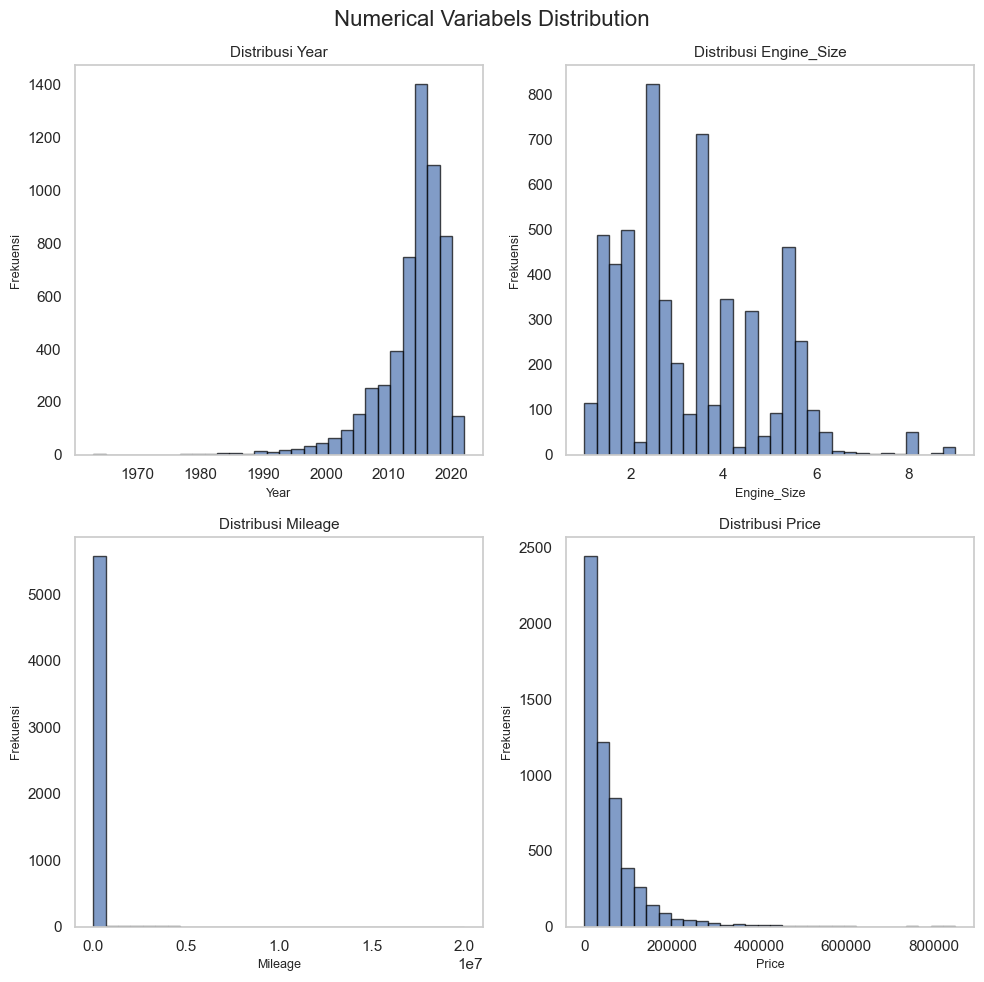

In [107]:
# Numerical Variabels
numeric_cols = ['Year', 'Engine_Size', 'Mileage', 'Price']

# Numerical Variabels Distribution
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
axes = axes.ravel()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=30, edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Distribusi {col}', fontsize=11)
    axes[i].set_xlabel(col, fontsize=9)
    axes[i].set_ylabel('Frekuensi', fontsize=9)
    axes[i].grid(False) 

fig.suptitle('Numerical Variabels Distribution', fontsize=16)
plt.tight_layout()
plt.show()

Based on the histograms above:

* The distributions of the numerical variables are not normally distributed.
* Appropriate treatment will be applied to the numerical variables, as **Year** exhibits a **left-skewed distribution**, while **Mileage** and **Price** exhibit **right-skewed distributions**.


# **3A. Data Cleaning**

At this stage, data cleaning will be performed, and the cleaned dataset will be used for subsequent analysis. The following steps will be carried out:

* Handling duplicate values.
* Handling outliers and extreme outliers.
* Dropping features that are not relevant to the business problem being addressed.


For the data cleaning, preprocessing, and feature engineering processes, a duplicated copy of the original dataframe will be used. This approach ensures that the original dataset remains unchanged and can be retained for reference purposes.


In [108]:
# Duplicate the dataframe for Preprocessing and Modelling

df_model = df.copy()

df_model

,Type,Region,Make,Gear_Type,Origin,Options,Year,Engine_Size,Mileage,Negotiable,Price
0,Corolla,Abha,Toyota,Manual,Saudi,Standard,2013,1.4,421000,True,0
1,Yukon,Riyadh,GMC,Automatic,Saudi,Full,2014,8.0,80000,False,120000
2,Range Rover,Riyadh,Land Rover,Automatic,Gulf Arabic,Full,2015,5.0,140000,False,260000
3,Optima,Hafar Al-Batin,Kia,Automatic,Saudi,Semi Full,2015,2.4,220000,False,42000
4,FJ,Riyadh,Toyota,Automatic,Saudi,Full,2020,4.0,49000,True,0
...,...,...,...,...,...,...,...,...,...,...,...
5619,X-Trail,Jeddah,Nissan,Automatic,Saudi,Standard,2018,2.5,78794,False,68000
5620,Altima,Jeddah,Nissan,Automatic,Saudi,Semi Full,2020,2.5,58000,True,0
5621,Yukon,Dammam,GMC,Automatic,Saudi,Full,2016,5.3,48000,False,145000
5622,RX,Dammam,Lexus,Automatic,Gulf Arabic,Full,2016,2.5,81000,False,154000


## **1. Duplicate Values Handling**

In [109]:
# check duplicates

df_model[df_model.duplicated(keep=False) == True].sort_values('Type')

,Type,Region,Make,Gear_Type,Origin,Options,Year,Engine_Size,Mileage,Negotiable,Price
3631,Camry,Riyadh,Toyota,Automatic,Saudi,Full,2013,2.5,185000,True,0
5267,Camry,Riyadh,Toyota,Automatic,Saudi,Full,2013,2.5,185000,True,0
540,Rio,Riyadh,Kia,Automatic,Saudi,Standard,2016,1.4,270000,False,25000
953,Rio,Riyadh,Kia,Automatic,Saudi,Standard,2016,1.4,270000,False,25000
236,Sonata,Jeddah,Hyundai,Automatic,Saudi,Standard,2020,2.4,100,False,72910
4646,Sonata,Jeddah,Hyundai,Automatic,Saudi,Standard,2020,2.4,100,False,72910
2012,Tucson,Dammam,Hyundai,Automatic,Saudi,Standard,2016,2.0,155000,False,45000
4933,Tucson,Dammam,Hyundai,Automatic,Saudi,Standard,2016,2.0,155000,False,45000


In [110]:
# check duplicate values

df_model[df_model.duplicated()]

,Type,Region,Make,Gear_Type,Origin,Options,Year,Engine_Size,Mileage,Negotiable,Price
953,Rio,Riyadh,Kia,Automatic,Saudi,Standard,2016,1.4,270000,False,25000
4646,Sonata,Jeddah,Hyundai,Automatic,Saudi,Standard,2020,2.4,100,False,72910
4933,Tucson,Dammam,Hyundai,Automatic,Saudi,Standard,2016,2.0,155000,False,45000
5267,Camry,Riyadh,Toyota,Automatic,Saudi,Full,2013,2.5,185000,True,0


In [111]:
# drop duplicate values

df_model.drop_duplicates(inplace=True)

In [112]:
# double check duplicate values after dropping the duplicated data

print(f'Duplicated values : {df_model.duplicated().sum()}')

Duplicated values : 0


## **2. Remove Unused Variabels**

In [113]:
# check Negotiable variable

print('Non Negotiable Data')
display(df_model[df_model['Negotiable']== False])
print('Negotiable Data')
display(df_model[df_model['Negotiable']== True])

Non Negotiable Data


,Type,Region,Make,Gear_Type,Origin,Options,Year,Engine_Size,Mileage,Negotiable,Price
1,Yukon,Riyadh,GMC,Automatic,Saudi,Full,2014,8.0,80000,False,120000
2,Range Rover,Riyadh,Land Rover,Automatic,Gulf Arabic,Full,2015,5.0,140000,False,260000
3,Optima,Hafar Al-Batin,Kia,Automatic,Saudi,Semi Full,2015,2.4,220000,False,42000
5,CX3,Abha,Mazda,Automatic,Saudi,Semi Full,2019,2.0,25000,False,58000
6,Cayenne S,Riyadh,Porsche,Automatic,Saudi,Full,2012,4.8,189000,False,85000
...,...,...,...,...,...,...,...,...,...,...,...
5616,CX9,Qassim,Mazda,Automatic,Saudi,Full,2020,2.0,9500,False,132000
5618,Suburban,Riyadh,GMC,Automatic,Saudi,Full,2006,5.3,86000,False,50000
5619,X-Trail,Jeddah,Nissan,Automatic,Saudi,Standard,2018,2.5,78794,False,68000
5621,Yukon,Dammam,GMC,Automatic,Saudi,Full,2016,5.3,48000,False,145000


Negotiable Data


,Type,Region,Make,Gear_Type,Origin,Options,Year,Engine_Size,Mileage,Negotiable,Price
0,Corolla,Abha,Toyota,Manual,Saudi,Standard,2013,1.4,421000,True,0
4,FJ,Riyadh,Toyota,Automatic,Saudi,Full,2020,4.0,49000,True,0
9,LS,Aseer,Lexus,Automatic,Saudi,Full,1998,4.6,300,True,0
14,Hilux,Yanbu,Toyota,Automatic,Saudi,Full,2014,2.7,209,True,0
15,Land Cruiser,Aseer,Toyota,Manual,Gulf Arabic,Semi Full,1982,4.6,340000,True,0
...,...,...,...,...,...,...,...,...,...,...,...
5610,Town Car,Jeddah,Lincoln,Automatic,Other,Full,1999,5.0,343,True,0
5614,Victoria,Makkah,Ford,Automatic,Saudi,Standard,2010,4.6,345000,True,0
5617,Yukon,Jubail,GMC,Automatic,Saudi,Semi Full,2006,5.3,300,True,0
5620,Altima,Jeddah,Nissan,Automatic,Saudi,Semi Full,2020,2.5,58000,True,0


In [114]:
# check Price = 0

df_model[df_model['Price'] == 0]

,Type,Region,Make,Gear_Type,Origin,Options,Year,Engine_Size,Mileage,Negotiable,Price
0,Corolla,Abha,Toyota,Manual,Saudi,Standard,2013,1.4,421000,True,0
4,FJ,Riyadh,Toyota,Automatic,Saudi,Full,2020,4.0,49000,True,0
9,LS,Aseer,Lexus,Automatic,Saudi,Full,1998,4.6,300,True,0
14,Hilux,Yanbu,Toyota,Automatic,Saudi,Full,2014,2.7,209,True,0
15,Land Cruiser,Aseer,Toyota,Manual,Gulf Arabic,Semi Full,1982,4.6,340000,True,0
...,...,...,...,...,...,...,...,...,...,...,...
5610,Town Car,Jeddah,Lincoln,Automatic,Other,Full,1999,5.0,343,True,0
5614,Victoria,Makkah,Ford,Automatic,Saudi,Standard,2010,4.6,345000,True,0
5617,Yukon,Jubail,GMC,Automatic,Saudi,Semi Full,2006,5.3,300,True,0
5620,Altima,Jeddah,Nissan,Automatic,Saudi,Semi Full,2020,2.5,58000,True,0


In [115]:
# check counts Negotiable variabel which Price = 0

df_model[df_model['Price'] == 0]['Negotiable'].value_counts()

Negotiable
True     1795
False       1
Name: count, dtype: int64

Based on the results above:

* There are 1,795 records with a `Price` value of 0 when the `Negotiable` variable is *True*. This indicates that the prices of negotiable used cars were not recorded in the `Price` variable.
* There is 1 record with a `Price` value of 0 when the `Negotiable` variable is *False*. This is not logically valid because a non-negotiable used cars should have a specified selling price. Therefore, this record will be removed.
* A used car price cannot realistically be zero. If these zero values are retained in the model, they may introduce bias because the model could interpret 0 as a valid price, potentially degrading the performance of the regression model. In reality, these values represent prices that have not been specified.
* The `Negotiable` variable is more closely related to the negotiation process rather than the actual market value of a used car. Since it does not directly influence the true selling price, this variable will be removed as it is not relevant to the used car price prediction model.

In [116]:
# drop variabel Negotiable

df_model = df_model.drop(columns='Negotiable')

# double check
df_model

,Type,Region,Make,Gear_Type,Origin,Options,Year,Engine_Size,Mileage,Price
0,Corolla,Abha,Toyota,Manual,Saudi,Standard,2013,1.4,421000,0
1,Yukon,Riyadh,GMC,Automatic,Saudi,Full,2014,8.0,80000,120000
2,Range Rover,Riyadh,Land Rover,Automatic,Gulf Arabic,Full,2015,5.0,140000,260000
3,Optima,Hafar Al-Batin,Kia,Automatic,Saudi,Semi Full,2015,2.4,220000,42000
4,FJ,Riyadh,Toyota,Automatic,Saudi,Full,2020,4.0,49000,0
...,...,...,...,...,...,...,...,...,...,...
5619,X-Trail,Jeddah,Nissan,Automatic,Saudi,Standard,2018,2.5,78794,68000
5620,Altima,Jeddah,Nissan,Automatic,Saudi,Semi Full,2020,2.5,58000,0
5621,Yukon,Dammam,GMC,Automatic,Saudi,Full,2016,5.3,48000,145000
5622,RX,Dammam,Lexus,Automatic,Gulf Arabic,Full,2016,2.5,81000,154000


## **3. Drop zero values**

In [117]:
# drop 0 values in Price

df_model = df_model[df_model['Price'] != 0]

In [118]:
# double check

df_model[df_model['Price'] == 0]

,Type,Region,Make,Gear_Type,Origin,Options,Year,Engine_Size,Mileage,Price


## **4. Remove Unknown Category in `Origin`**

In [119]:
# check count of unique values in Origin

df['Origin'].value_counts()

Origin
Saudi          4188
Gulf Arabic     697
Other           678
Unknown          61
Name: count, dtype: int64

- Based on the findings from the Data Understanding stage, the Origin variable contains an "Unknown" category, indicating that the used cars' origin is not identified. This category will be removed during the data cleaning process.
- The "Unknown" category will not be merged with "Other", as used cars that categorized as "Other" may still have a known origin that simply does not belong to the major origin categories represented in the dataset.

In [120]:
# Drop Unknown in Origin
df_model = df_model[df_model["Origin"] != "Unknown"]

df_model

,Type,Region,Make,Gear_Type,Origin,Options,Year,Engine_Size,Mileage,Price
1,Yukon,Riyadh,GMC,Automatic,Saudi,Full,2014,8.0,80000,120000
2,Range Rover,Riyadh,Land Rover,Automatic,Gulf Arabic,Full,2015,5.0,140000,260000
3,Optima,Hafar Al-Batin,Kia,Automatic,Saudi,Semi Full,2015,2.4,220000,42000
5,CX3,Abha,Mazda,Automatic,Saudi,Semi Full,2019,2.0,25000,58000
6,Cayenne S,Riyadh,Porsche,Automatic,Saudi,Full,2012,4.8,189000,85000
...,...,...,...,...,...,...,...,...,...,...
5616,CX9,Qassim,Mazda,Automatic,Saudi,Full,2020,2.0,9500,132000
5618,Suburban,Riyadh,GMC,Automatic,Saudi,Full,2006,5.3,86000,50000
5619,X-Trail,Jeddah,Nissan,Automatic,Saudi,Standard,2018,2.5,78794,68000
5621,Yukon,Dammam,GMC,Automatic,Saudi,Full,2016,5.3,48000,145000


## **5. Handling Outliers and Anomalies**

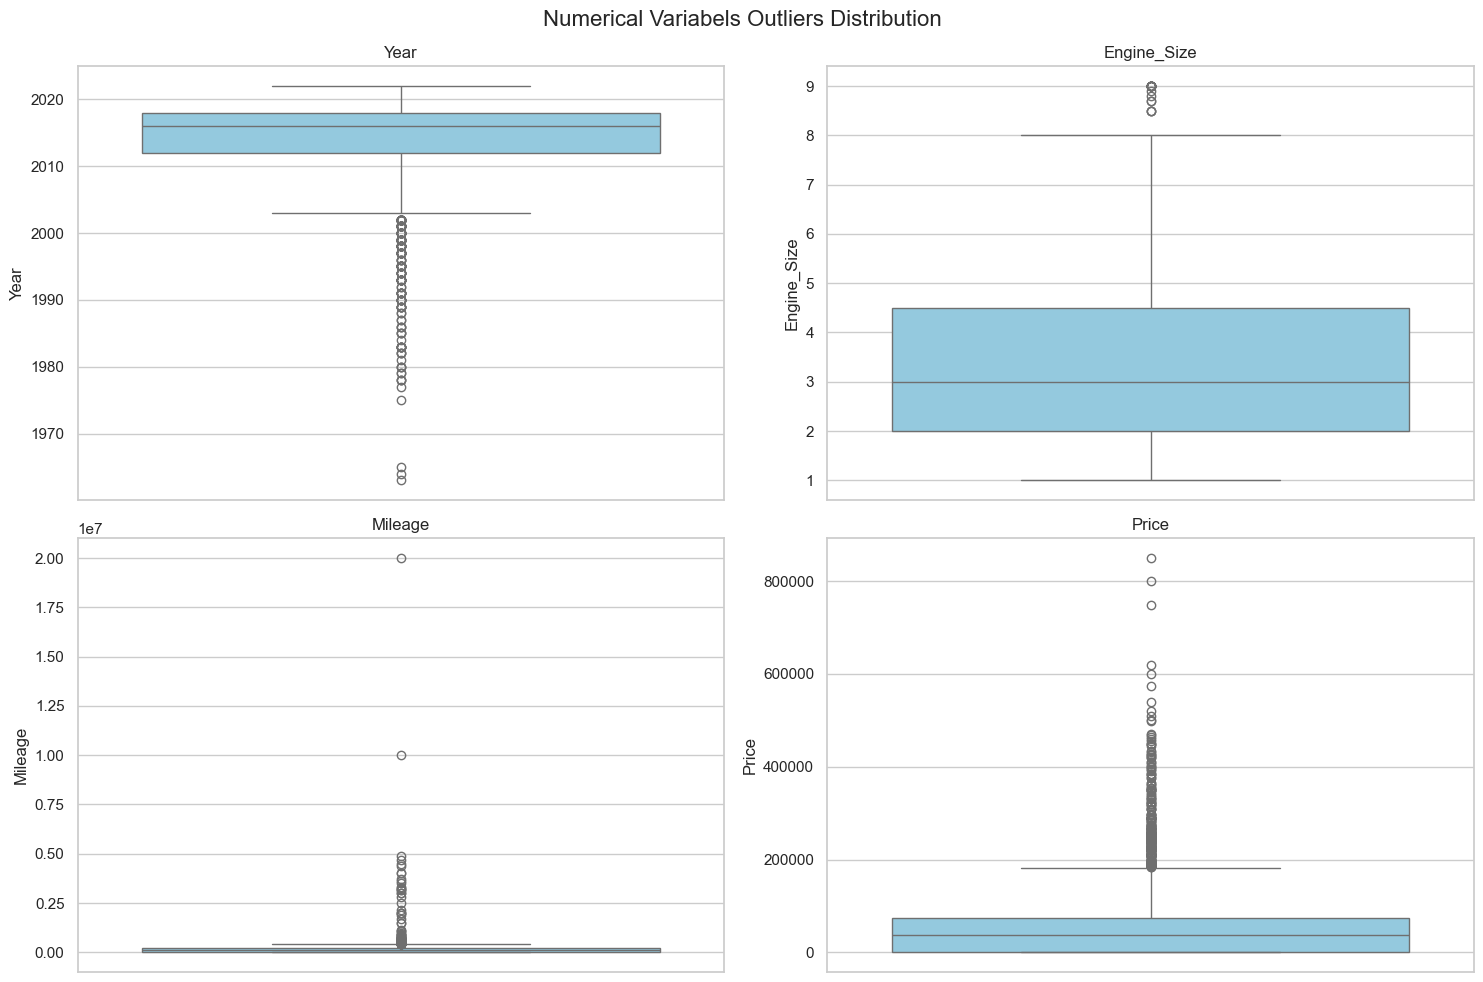

In [121]:
# Outliers in Numerical Variabels

numeric_cols = ['Year', 'Engine_Size', 'Mileage', 'Price']

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df, y=col, ax=axes[i], color='skyblue')
    axes[i].set_title(col)
    axes[i].set_xlabel("")
    axes[i].set_ylabel(col)

for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle('Numerical Variabels Outliers Distribution', fontsize=16)
plt.tight_layout()
plt.show()

**Numerical Variables Distribution**:

**1. Year**
* Most used cars in the dataset were manufactured between 2010 and 2022.
* There are several outliers representing older used cars, including some manufactured before 2000 and even a few produced before 1970.

**2. Engine_Size**
* Most used cars have an engine size ranging from 1 to 8 liters.
* Several outliers exist above 8 liters, indicating used cars with exceptionally large engine capacities.

**3. Mileage**
* The majority of used cars have a mileage below 500,000 kilometers.
* However, there are extremely large outliers, with mileage values reaching up to 20,000,000 kilometers. These values are highly implausible and are likely the result of data entry or recording errors. If left untreated, they may negatively affect the performance of the predictive model.

**4. Price**
* Most used cars prices fall within the low to mid-price range (below 200,000 Saudi Riyals).
* There are several extreme outliers with used car prices exceeding 600,000 Saudi Riyals.

### **Handling Outliers (mild dan extreme)**

**Check the numbers of Mild & Extreme Outliers**

In [122]:
# Count mild & extreme outliers
def count_outliers(data, column):
    q1 = data[column].quantile(0.25)
    q3 = data[column].quantile(0.75)
    iqr = q3 - q1

    # Mild outlier thresholds (1.5 * IQR)
    mild_lower = q1 - 1.5 * iqr
    mild_upper = q3 + 1.5 * iqr

    # Extreme outlier thresholds (3 * IQR)
    extreme_lower = q1 - 3 * iqr
    extreme_upper = q3 + 3 * iqr

    # Extreme outliers
    extreme_outliers = data[
        (data[column] < extreme_lower) | (data[column] > extreme_upper)
    ]

    # Mild outliers
    mild_outliers = data[
        ((data[column] < mild_lower) | (data[column] > mild_upper)) &
        ~((data[column] < extreme_lower) | (data[column] > extreme_upper))
    ]

    return {
        "mild_count": len(mild_outliers),
        "extreme_count": len(extreme_outliers),
        "mild_lower": mild_lower,
        "mild_upper": mild_upper,
        "extreme_lower": extreme_lower,
        "extreme_upper": extreme_upper
    }

listing = []

for col in numeric_cols:  
    result = count_outliers(df_model, col)
    listing.append([
        col,
        result['mild_count'],
        result['extreme_count'],
        result['mild_lower'],
        result['mild_upper'],
        result['extreme_lower'],
        result['extreme_upper']
    ])

# summary dataframe
outliers_summary = pd.DataFrame(
    listing,
    columns=[
        'Variable',
        'Mild Outliers Count',
        'Extreme Outliers Count',
        'Mild Lower',
        'Mild Upper',
        'Extreme Lower',
        'Extreme Upper'
    ]
)

outliers_summary

,Variable,Mild Outliers Count,Extreme Outliers Count,Mild Lower,Mild Upper,Extreme Lower,Extreme Upper
0,Year,125,57,2005.50,2025.50,1998.0,2033.0
1,Engine_Size,30,0,-1.00,7.00,-4.0,10.0
2,Mileage,101,29,-153290.25,383483.75,-354580.5,584774.0
3,Price,157,96,-55000.00,185000.00,-145000.0,275000.0


Based on the table above:
- Both mild outliers and extreme outliers are present in the dataset. Therefore, outlier handling treatment will be applied to each numerical variable, including the use of appropriate thresholds, to ensure higher data quality and improve the reliability of the dataset before building the machine learning model.


**Thresholds for Outlier Handling**

> Used Cars Price (According to several references)

**a. Minimum Price of Used Cars in Saudi Arabian Online Marketplaces**

* On YallaMotor, there are used car listings priced below **10,000 SAR**. [Yallamotor.com](https://ksa.yallamotor.com/used-cars/under-10000-sar)
* Hatla2ee also features used cars within the **7,500–10,000 SAR** price range. [Hatla2ee](https://ksa.hatla2ee.com/en/car/price-limit/10000)
* Syarah provides a dedicated category for **“Used Cars in Riyadh Under 10,000 SAR.** [Syarah.com](https://syarah.com/en/trend/used-cars-riyadh-under-10000)

**b. Maximum Price of Used Cars in Saudi Arabian Online Marketplaces**

* On CarSwitch, used SUVs and large used cars such as the Ford Expedition can reach prices of approximately **225,000 SAR**. [CarSwitch](https://ksa.carswitch.com/en/saudi/used-cars)
* YallaMotor also lists premium used cars, such as the Mercedes S-Class, with prices exceeding **220,000 SAR**. [Yallamotor.com](https://ksa.yallamotor.com/used-cars/saudi-arabia056)
* Therefore, luxury and premium used cars can reasonably be priced above 200,000 SAR in the Saudi Arabian online marketplace.

---

> **Threshold Settings for Numerical Variables**

* **Year:** **1998–2022** (upper and lower thresholds are determined based on the numerical variable boxplot distribution to reduce skewness).
* **Engine Size:** **1.0–9.0 liters** (no outlier treatment will be applied; all existing values will be retained).
* **Mileage:** **100–584,744 km** (the lower threshold is based on references from Syarah.com, while the upper threshold is based on the previously identified mild outlier threshold).
* **Price:** **5,000–600,000 SAR** (the lower threshold is determined based on multiple market references, while the upper threshold is based on the numerical variable outlier distribution boxplot and is intended to reduce skewness).


In [123]:
# check Year variable

df_model[['Year']].value_counts().reset_index().sort_values('Year', ascending = False)

,Year,count
10,2021,94
5,2020,273
4,2019,360
2,2018,437
1,2017,438
0,2016,607
3,2015,388
6,2014,250
7,2013,209
9,2012,119


In [124]:
# Check Price variable

df_model[['Price']].sort_values('Price').tail(25)

,Price
5149,425000
1904,425000
808,428000
1082,431500
4377,435000
4363,445000
3071,450000
4378,450000
3896,450000
3182,455000


* There is a `Price` value of **1 SAR**, along with several other `Price` values that appear unrealistically low and are unlikely to represent the true market value of used cars.

In [125]:
# Check Engine_Size variable

df_model[['Engine_Size']].sort_values('Engine_Size')

,Engine_Size
5272,1.0
1945,1.0
542,1.0
3987,1.0
765,1.0
...,...
1547,9.0
3525,9.0
2217,9.0
5251,9.0


In [126]:
# Check Mileage variable

df_model[['Mileage']].sort_values('Mileage')

,Mileage
843,100
1130,100
236,100
1276,100
3071,100
...,...
4548,3300000
1412,3500000
4193,3640000
572,4500000


**Remove Outliers**

`Year`

In [127]:
# removing Year below 1998

df_model = df_model[
    (df_model["Year"] >= 1998) &
    (df_model["Year"] <= 2022)
]

`Engine_Size`

In [128]:
# not removing any outliers

df_model = df_model[
    (df_model["Engine_Size"] >= 1.0) &
    (df_model["Engine_Size"] <= 9)
]

`Mileage`

In [129]:
# removing Mileage below 100 and above 587444

df_model = df_model[
    (df_model["Mileage"] >= 100) &
    (df_model["Mileage"] <= 587444)
]

`Price`

In [130]:
# removing Price below 5000 and above 600000

df_model = df_model[
    (df_model["Price"] >= 5000) &
    (df_model["Price"] <= 600000)
]

In [131]:
# check the data after cleaning

df_model

,Type,Region,Make,Gear_Type,Origin,Options,Year,Engine_Size,Mileage,Price
1,Yukon,Riyadh,GMC,Automatic,Saudi,Full,2014,8.0,80000,120000
2,Range Rover,Riyadh,Land Rover,Automatic,Gulf Arabic,Full,2015,5.0,140000,260000
3,Optima,Hafar Al-Batin,Kia,Automatic,Saudi,Semi Full,2015,2.4,220000,42000
5,CX3,Abha,Mazda,Automatic,Saudi,Semi Full,2019,2.0,25000,58000
6,Cayenne S,Riyadh,Porsche,Automatic,Saudi,Full,2012,4.8,189000,85000
...,...,...,...,...,...,...,...,...,...,...
5616,CX9,Qassim,Mazda,Automatic,Saudi,Full,2020,2.0,9500,132000
5618,Suburban,Riyadh,GMC,Automatic,Saudi,Full,2006,5.3,86000,50000
5619,X-Trail,Jeddah,Nissan,Automatic,Saudi,Standard,2018,2.5,78794,68000
5621,Yukon,Dammam,GMC,Automatic,Saudi,Full,2016,5.3,48000,145000


In [132]:
# check again the numbers of mild and extreme outliers after removing outliers

# Count mild & extreme outliers
def count_outliers(data, column):
    q1 = data[column].quantile(0.25)
    q3 = data[column].quantile(0.75)
    iqr = q3 - q1

    # Mild outlier thresholds (1.5 * IQR)
    mild_lower = q1 - 1.5 * iqr
    mild_upper = q3 + 1.5 * iqr

    # Extreme outlier thresholds (3 * IQR)
    extreme_lower = q1 - 3 * iqr
    extreme_upper = q3 + 3 * iqr

    # Extreme outliers
    extreme_outliers = data[
        (data[column] < extreme_lower) | (data[column] > extreme_upper)
    ]

    # Mild outliers
    mild_outliers = data[
        ((data[column] < mild_lower) | (data[column] > mild_upper)) &
        ~((data[column] < extreme_lower) | (data[column] > extreme_upper))
    ]

    return {
        "mild_count": len(mild_outliers),
        "extreme_count": len(extreme_outliers),
        "mild_lower": mild_lower,
        "mild_upper": mild_upper,
        "extreme_lower": extreme_lower,
        "extreme_upper": extreme_upper
    }

listing = []

for col in numeric_cols:
    result = count_outliers(df_model, col)
    listing.append([
        col,
        result['mild_count'],
        result['extreme_count'],
        result['mild_lower'],
        result['mild_upper'],
        result['extreme_lower'],
        result['extreme_upper']
    ])

# Buat dataframe summary
outliers_summary = pd.DataFrame(
    listing,
    columns=[
        'Variable',
        'Mild Outliers Count',
        'Extreme Outliers Count',
        'Mild Lower',
        'Mild Upper',
        'Extreme Lower',
        'Extreme Upper'
    ]
)

# Tampilkan hasil
outliers_summary

,Variable,Mild Outliers Count,Extreme Outliers Count,Mild Lower,Mild Upper,Extreme Lower,Extreme Upper
0,Year,188,34,2008.0,2024.0,2002.0,2030.0
1,Engine_Size,29,0,-1.0,7.0,-4.0,10.0
2,Mileage,110,1,-146217.5,375730.5,-341948.0,571461.0
3,Price,156,100,-49375.0,181625.0,-136000.0,268250.0


* After the cleaning process, the number of extreme outliers in **`Year`**, **`Engine_Size`**, **`Mileage`**, and **`Price`** has been significantly reduced.
* However, the remaining outliers will not be removed in this analysis, as they may contain valuable information and could contribute to improving the performance of the machine learning prediction model.


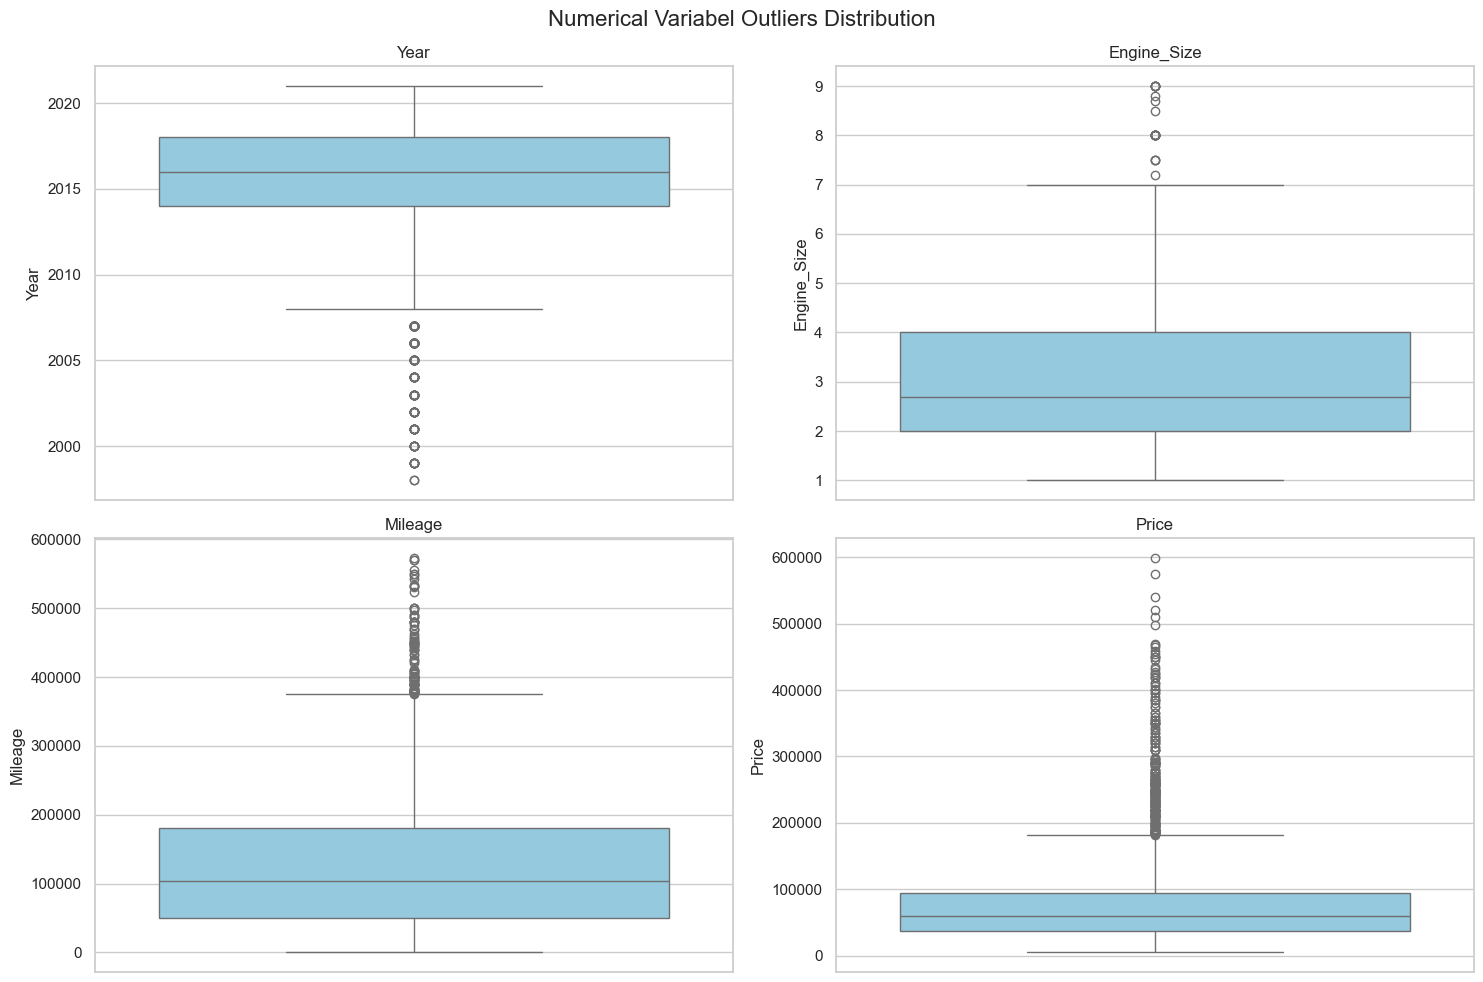

In [133]:
# visualization for outliers distribution with boxplot after outliers handling

numeric_cols = ['Year', 'Engine_Size', 'Mileage', 'Price']

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.boxplot(data=df_model, y=col, ax=axes[i], color='skyblue')
    axes[i].set_title(col)
    axes[i].set_xlabel("")
    axes[i].set_ylabel(col)

for j in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[j])

fig.suptitle('Numerical Variabel Outliers Distribution', fontsize=16)
plt.tight_layout()
plt.show()


From the boxplots above, it can be observed that the number of outliers has decreased after the data cleaning process.


## **6. Replace Brand name 'Škoda' in `Make`**

Replace 'Š' with 'S' in Skoda name

In [134]:
# replace Škoda in Make

df_model['Make'] = df_model['Make'].replace('Škoda', 'Skoda')

df_model['Make'].unique()

array(['GMC', 'Land Rover', 'Kia', 'Mazda', 'Porsche', 'Hyundai',
       'Toyota', 'Chrysler', 'Lexus', 'Nissan', 'Mitsubishi', 'Ford',
       'MG', 'Chevrolet', 'Mercedes', 'Jeep', 'BMW', 'Lincoln', 'Genesis',
       'Honda', 'Zhengzhou', 'Dodge', 'HAVAL', 'Cadillac', 'Changan',
       'Aston Martin', 'Renault', 'Suzuki', 'Mercury', 'INFINITI', 'Audi',
       'Rolls-Royce', 'BYD', 'Volkswagen', 'Victory Auto', 'Geely',
       'Isuzu', 'Daihatsu', 'Maserati', 'Other', 'Hummer', 'GAC', 'Lifan',
       'Bentley', 'Chery', 'Jaguar', 'Peugeot', 'Foton', 'MINI', 'Skoda',
       'Fiat', 'Iveco', 'FAW', 'Great Wall', 'Ferrari'], dtype=object)

**Save Cleaned Data to CSV**

In [135]:
df_model.to_csv("usedcars_data_cleaned.csv", index=False)

# **3B. Exploratory Data Analysis**

## **`Price` vs Numerical Features `Year`, `Engine_Size`, `Mileage` by `Gear_Type` and `Options`**

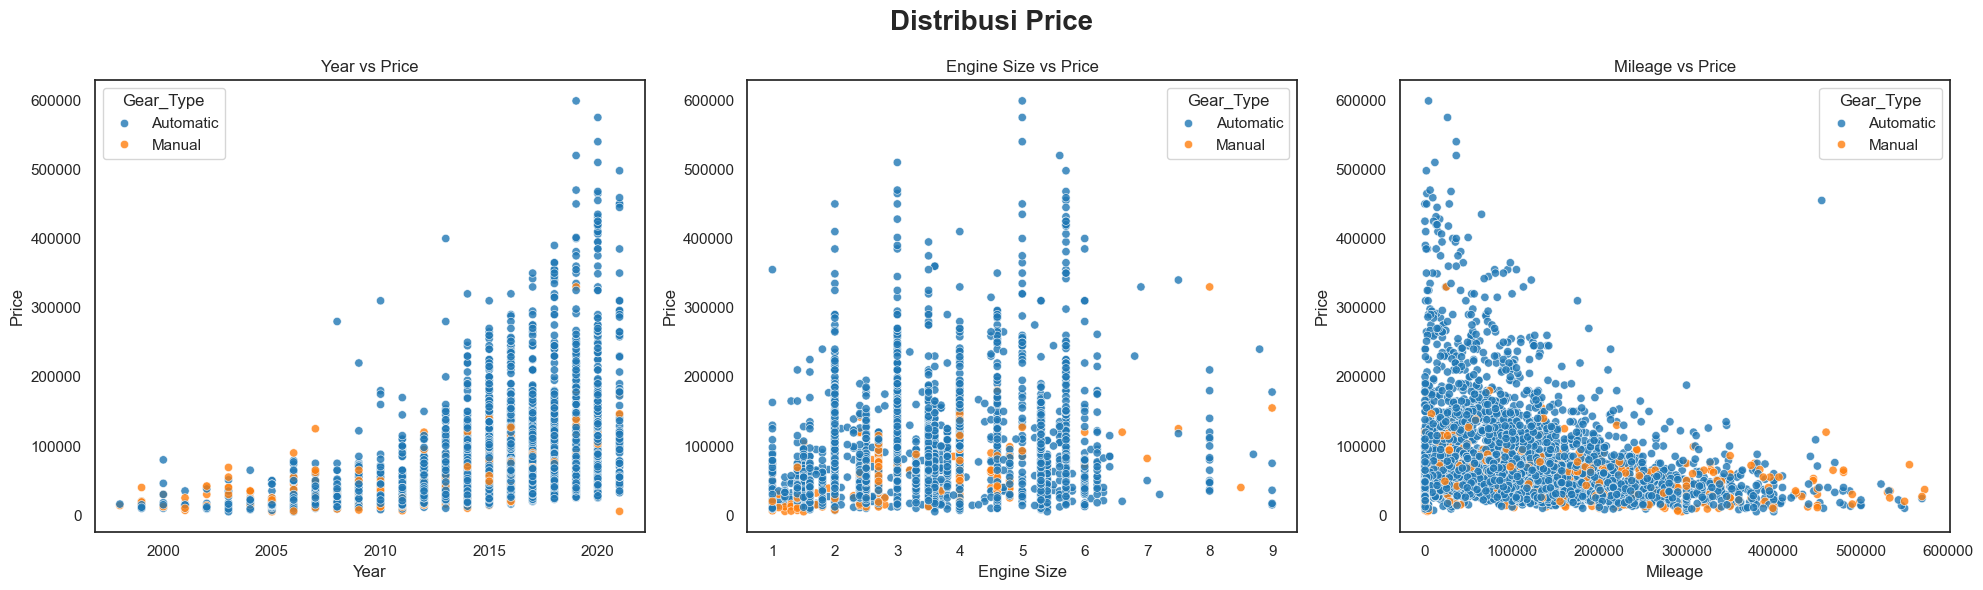

In [136]:
# Price vs Numerical Features by each Gear Type

sns.set(style="white")

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Title
fig.suptitle("Distribusi Price", fontsize=20, fontweight="bold")

# Palette
custom_palette = ["#1f77b4", "#ff7f0e"]

# 1. Year vs Price
sns.scatterplot(
    data=df_model,
    x="Year",
    y="Price",
    hue="Gear_Type",
    palette=custom_palette,
    alpha=0.8,
    ax=axes[0]
)
axes[0].set_title("Year vs Price")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Price")
axes[0].grid(False)

# 2. Engine Size vs Price
sns.scatterplot(
    data=df_model,
    x="Engine_Size",
    y="Price",
    hue="Gear_Type",
    palette=custom_palette,
    alpha=0.8,
    ax=axes[1]
)
axes[1].set_title("Engine Size vs Price")
axes[1].set_xlabel("Engine Size")
axes[1].set_ylabel("Price")
axes[1].grid(False)

# 3. Mileage vs Price
sns.scatterplot(
    data=df_model,
    x="Mileage",
    y="Price",
    hue="Gear_Type",
    palette=custom_palette,
    alpha=0.8,
    ax=axes[2]
)
axes[2].set_title("Mileage vs Price")
axes[2].set_xlabel("Mileage")
axes[2].set_ylabel("Price")
axes[2].grid(False)

plt.tight_layout(rect=[0, 0, 1, 1])
plt.show()


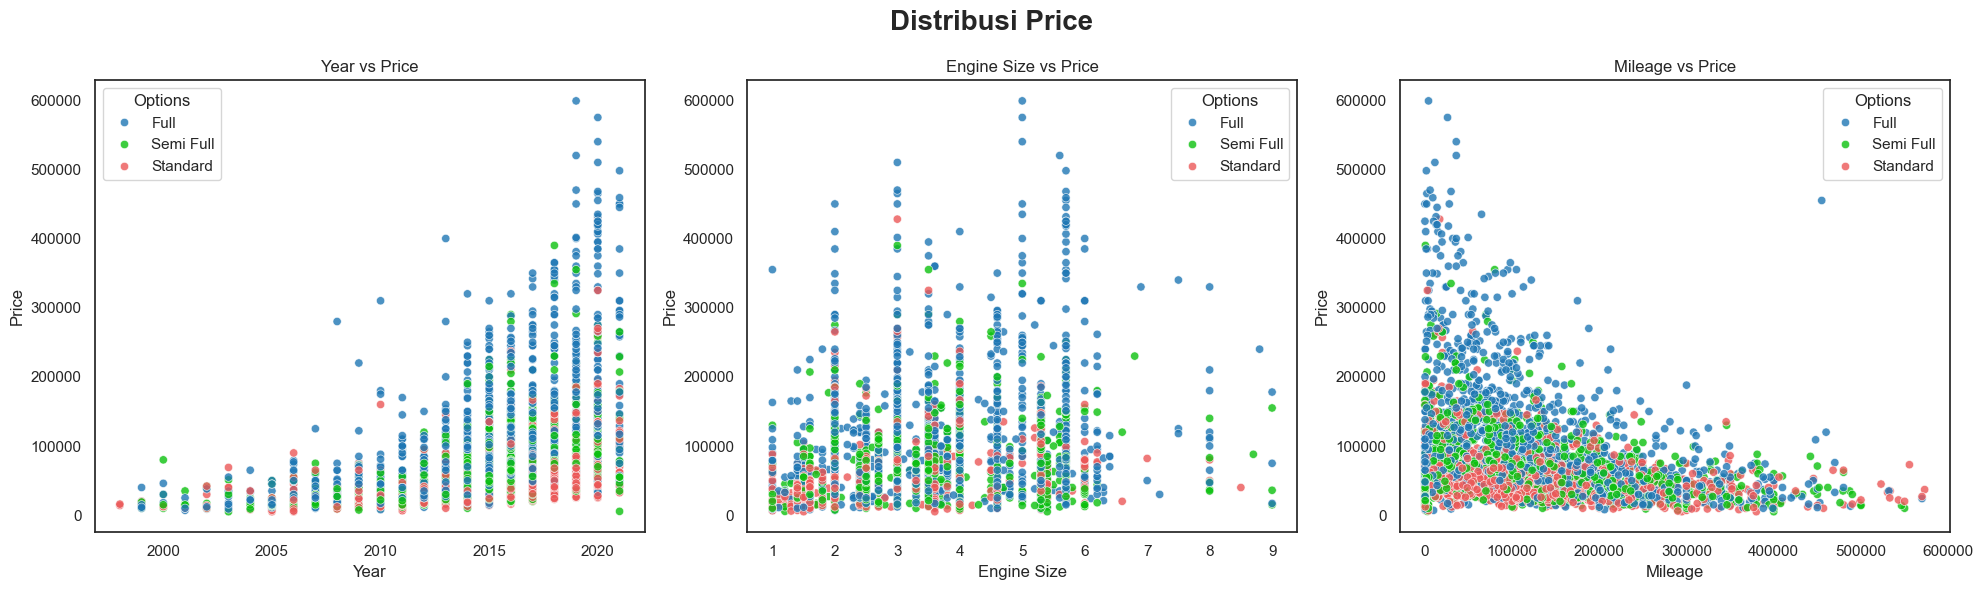

In [137]:
# Price Distribution vs Numerical Features by each Options

sns.set(style="white")

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Title 
fig.suptitle("Distribusi Price", fontsize=20, fontweight="bold")

# Palette
custom_palette = ["#1f77b4", "#0CC10F", "#eb5858"]

# 1. Year vs Price
sns.scatterplot(
    data=df_model,
    x="Year",
    y="Price",
    hue="Options",
    palette=custom_palette,
    alpha=0.8,
    ax=axes[0]
)
axes[0].set_title("Year vs Price")
axes[0].set_xlabel("Year")
axes[0].set_ylabel("Price")
axes[0].grid(False)

# 2. Engine Size vs Price
sns.scatterplot(
    data=df_model,
    x="Engine_Size",
    y="Price",
    hue="Options",
    palette=custom_palette,
    alpha=0.8,
    ax=axes[1]
)
axes[1].set_title("Engine Size vs Price")
axes[1].set_xlabel("Engine Size")
axes[1].set_ylabel("Price")
axes[1].grid(False)

# 3. Mileage vs Price
sns.scatterplot(
    data=df_model,
    x="Mileage",
    y="Price",
    hue="Options",
    palette=custom_palette,
    alpha=0.8,
    ax=axes[2]
)
axes[2].set_title("Mileage vs Price")
axes[2].set_xlabel("Mileage")
axes[2].set_ylabel("Price")
axes[2].grid(False)

plt.tight_layout(rect=[0, 0, 1, 1])
plt.show()


**Features (Numerical & Categorical) vs Target:**

**1. Year vs Price**

* The plot shows a clear positive relationship between used cars year and price.
* Newer used cars tend to have higher selling prices.
* This indicates that used cars age is an important factor in determining price.

**2. Engine Size vs Price**

* The relationship between Engine Size and Price shows a positive trend.
* Used cars with larger engine capacities generally have higher prices, although the distribution exhibits considerable variation.
* This indicates that engine size is a factor correlated with used cars price.

**3. Mileage vs Price**
* The plot shows a negative relationship between mileage and price.
* As mileage increases, used cars prices tend to decrease.
* This indicates that mileage is a key indicator of used cars condition and has a significant influence on perceived market value.

**4. Gear Type vs Price**
* Used cars with Automatic transmission generally have higher prices than those with Manual transmission.
* This indicates that Gear Type is an important factor in determining price.

**5. Options vs Price**

* Used cars with Full Options consistently fall within the highest price range, while Semi Full used cars occupy the mid-range, and Standard used cars tend to have the lowest prices.
* This indicates that Options is an important factor in determining price.


In [138]:
# Avg Price based on Type, Region, Origin, and Make (Manufacturer Company)

avg_price_region = df_model[['Region', 'Price']].groupby('Region').median().reset_index().sort_values('Price', ascending=False)
avg_price_origin = df_model[['Origin', 'Price']].groupby('Origin').median().reset_index().sort_values('Price', ascending=False)
avg_price_make = df_model[['Make', 'Price']].groupby('Make').median().reset_index().sort_values('Price', ascending=False)

## **Average `Price` by `Region`, `Origin` dan `Make`**

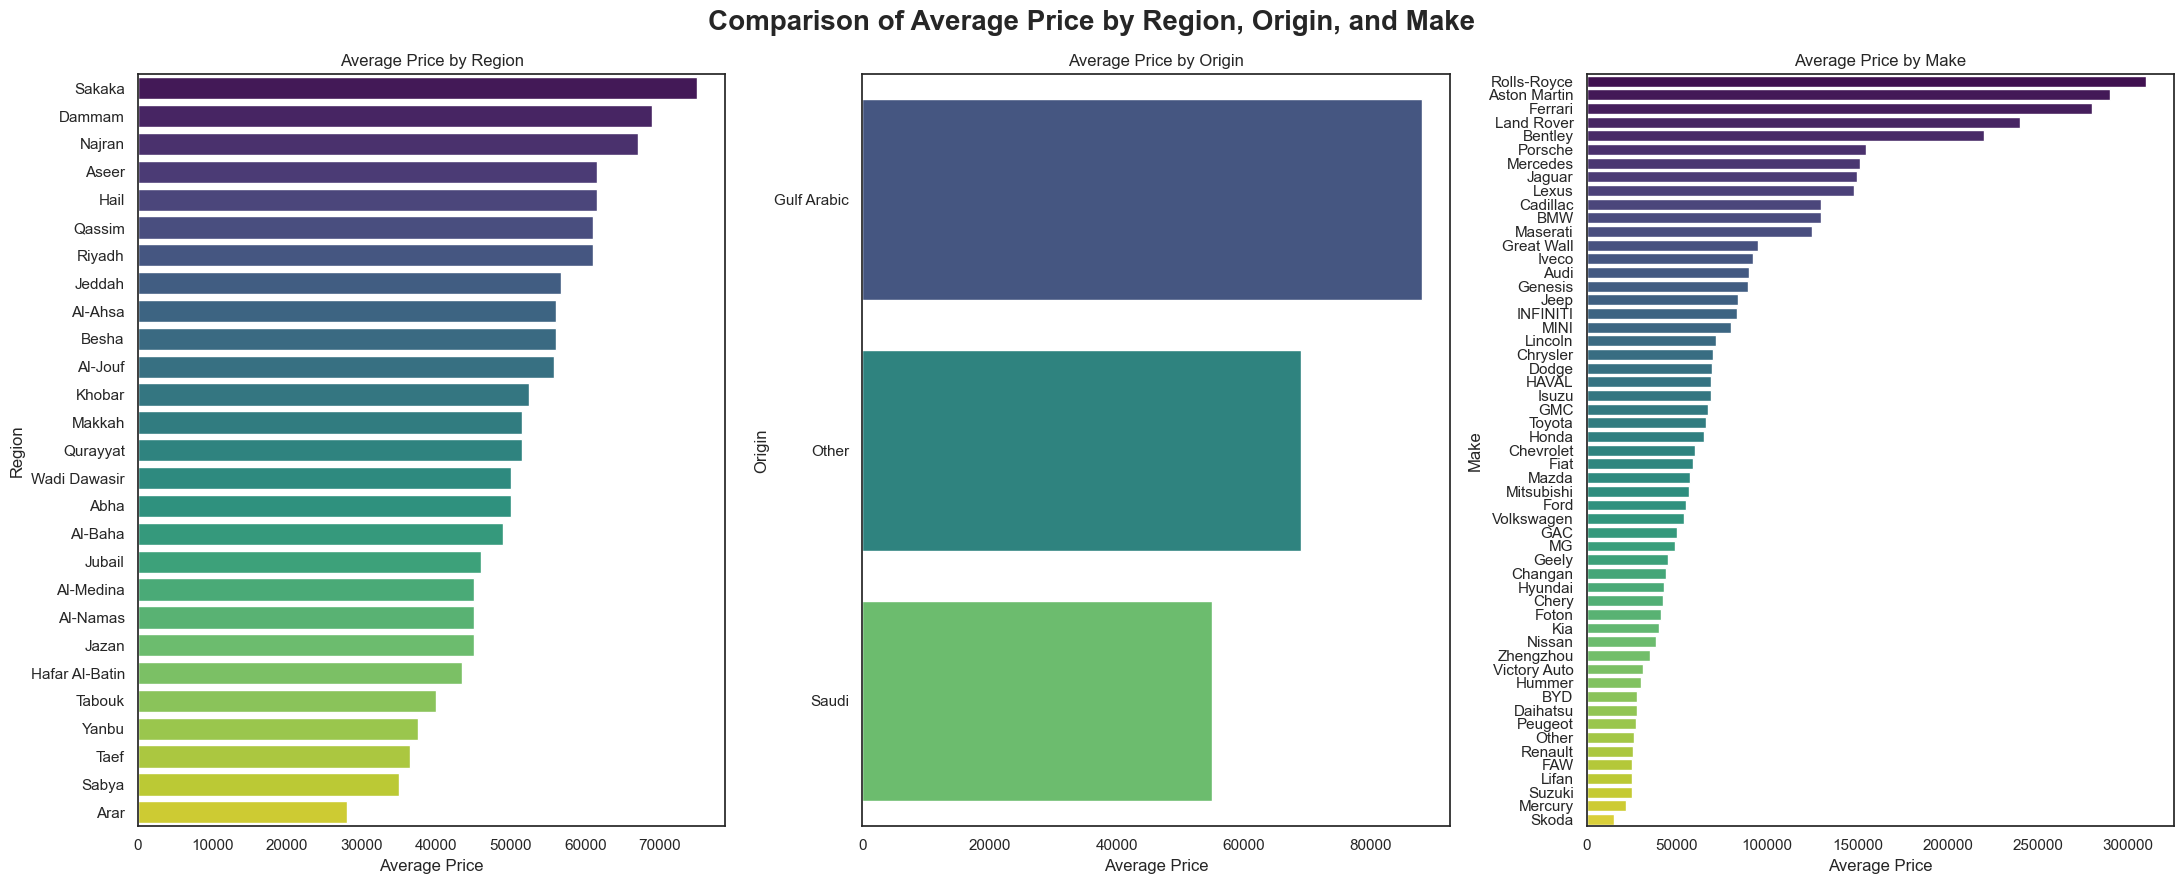

In [139]:
# Avg Price based on Type, Region, Origin, and Make (Manufacturer Company) visualization

sns.set_style("white")

fig, axes = plt.subplots(1, 3, figsize=(22, 9))
fig.suptitle('Comparison of Average Price by Region, Origin, and Make', 
             fontsize=20, fontweight='bold')

# 1. Region
sns.barplot(
    data=avg_price_region,
    x='Price',
    y='Region',
    palette='viridis',
    ax=axes[0]
)
axes[0].set_title('Average Price by Region')
axes[0].set_xlabel('Average Price')
axes[0].set_ylabel('Region')
axes[0].grid(False) 

# 2. Origin
sns.barplot(
    data=avg_price_origin,
    x='Price',
    y='Origin',
    palette='viridis',
    ax=axes[1]
)
axes[1].set_title('Average Price by Origin')
axes[1].set_xlabel('Average Price')
axes[1].set_ylabel('Origin')
axes[1].grid(False)

# 3. Make
sns.barplot(
    data=avg_price_make,
    x='Price',
    y='Make',
    palette='viridis',
    ax=axes[2]
)
axes[2].set_title('Average Price by Make')
axes[2].set_xlabel('Average Price')
axes[2].set_ylabel('Make')
axes[2].grid(False) 

plt.tight_layout(rect=[0, 0, 1, 1])
plt.show()

**Features (Categorical) vs Target:**

**1. Average Price by Region**

* The analysis reveals noticeable differences in average used cars prices across regions.
* Regions such as Sakaka and Dammam have the highest average prices, suggesting that the used cars sold in these areas are likely to have higher specifications or belong to premium market segments.
* Regions such as Makkah and Qurayyat have the mid average prices.
* In contrast, regions such as Sabya and Qurrayat exhibit lower average prices, indicating markets that are more dominated by economical and budget-oriented used cars.
* These findings suggest that geographic location is correlated with used car prices, as regions differ in terms of purchasing power, minimum wage levels, and whether they are classified as metropolitan or non-metropolitan areas.

**2. Average Price by Origin**

* Used cars categorized under Gulf Arabic origins have the highest average prices, followed by Other, while Saudi used cars have the lowest average prices.
* This indicates that used cars origin is correlated with used car prices.

**3. Average Price by Make**

* Brands such as Rolls-Royce, Aston Martin, Ferrari, Land Rover dominate the highest average price rankings, representing the premium and luxury segments of the used car market.
* Brands such as MINI, Isuzu, Toyota, Hyundai, Nissan, Kia, Mitsubishi occupy the middle-to-lower price ranges, reflecting the dominance of mid-range and economical used cars in the market.
* Brands at the lower end, such as Lifan, FAW, and BYD, represent budget-oriented used cars segments.
* These findings indicate that used cars brand is one of the factors that influence of used car prices.
* In general, the stronger the brand reputation, the higher the average resale value of its used used cars.


## **Correlation Heatmap**

In [140]:
# Correlation Numerical Features with Target (Price)

corr = df[['Year', 'Engine_Size', 'Mileage', 'Price']].corr('spearman')

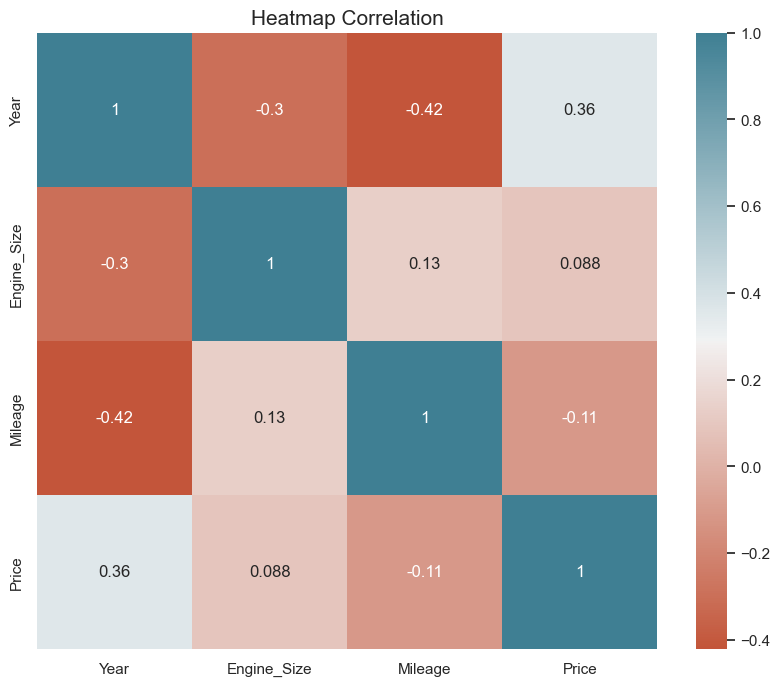

In [141]:
# Heatmap correlation visualization

plt.figure(figsize=(10, 8))
palette = sns.diverging_palette(20, 220, n=256)
sns.heatmap(corr, annot=True, cmap=palette)
plt.title('Heatmap Correlation', size = 15)
plt.show()

Heatmap correlation results:

1. **Year vs Price:** **0.36** (weak & positive correlation). This indicates that newer used cars tend to have higher selling prices.
2. **Engine Size vs Price:** **0.0088** (very weak & positive correlation). This suggests that used cars with larger engine capacities tend to be slightly more expensive, although the relationship is extremely weak.
3. **Mileage vs Price:** **-0.11** (very weak & negative correlation). This indicates that as used cars mileage increases, the selling price tends to decrease slightly.
4. **Year vs Mileage:** **-0.42** (moderate & negative correlation). This suggests that newer used cars generally have lower mileage compared to older used cars.


# **3C. Data Preprocessing**

## **Check Multicollinearity**

Multicollinearity occurs when two or more independent variables (features) in a regression model are highly correlated with one another, resulting in redundant information being introduced into the model. In other words, the features have strong linear relationships with each other rather than solely with the target variable. When two features are highly correlated, the model may struggle to determine which feature is actually influencing the target variable. Checking multicollinearity is important because it can make regression models unstable, difficult to interpret, less reliable, and more prone to overfitting.

**Variance Inflation Factor (VIF)** is used to measure the extent to which a feature is influenced by other features in the dataset. A **VIF value greater than 10** is generally considered a strong indication of multicollinearity and suggests that the feature should be carefully reviewed and potentially removed or otherwise addressed.

In [142]:
# import library for VIF calculation
from statsmodels.stats.outliers_influence import variance_inflation_factor

num_features = ['Year', 'Engine_Size', 'Mileage']

# VIF calculation
def calculate_vif(df_model):
    vif_list = []
    
    for cols in range(len(num_features)):
        vif_value = variance_inflation_factor(df_model.values, cols)
        vif_list.append(vif_value)
    
    return pd.DataFrame({
        "Variable": df_model.columns,
        "VIF": vif_list
    })

calculate_vif(df_model[num_features])

,Variable,VIF
0,Year,6.458704
1,Engine_Size,5.891104
2,Mileage,2.523964


Based on the **Variance Inflation Factor (VIF)** results:

* **`Year`**: ~6.46
* **`Engine_Size`**: ~5.89
* **`Mileage`**: ~2.53

All VIF values are **below 10**, indicating that there is no significant multicollinearity among the numerical features. Therefore, these features can be retained in the model without requiring further removal or modification.


## **Feature Engineering**

Feature engineering is the process of transforming raw data into more meaningful and relevant features so that machine learning models can learn more effectively. The objective is to improve model performance by selecting, creating, or transforming features that are able to capture important patterns within the data.


In [143]:
df_model.head()

,Type,Region,Make,Gear_Type,Origin,Options,Year,Engine_Size,Mileage,Price
1,Yukon,Riyadh,GMC,Automatic,Saudi,Full,2014,8.0,80000,120000
2,Range Rover,Riyadh,Land Rover,Automatic,Gulf Arabic,Full,2015,5.0,140000,260000
3,Optima,Hafar Al-Batin,Kia,Automatic,Saudi,Semi Full,2015,2.4,220000,42000
5,CX3,Abha,Mazda,Automatic,Saudi,Semi Full,2019,2.0,25000,58000
6,Cayenne S,Riyadh,Porsche,Automatic,Saudi,Full,2012,4.8,189000,85000


### **Feature Selection**

Feature selection is the process of choosing variables that are considered influential in determining used car selling prices. The **`Negotiable`** variable, which was removed earlier during the data cleaning stage, has been confirmed to have no direct relationship with the selling price. Therefore, it will not be included in the analysis or modeling process. Based on EDA, heatmap, multicolinearity and reference, all features will be used for modelling.

In [144]:
x = df_model.drop(['Price'], axis=1)
y = df_model['Price']

### **Split Train and Test Data**

Split the data, train set = 80% and test set = 20%.

In [145]:
xtrain, xtest, ytrain, ytest = train_test_split(
    x, 
    y, 
    test_size= 0.2, 
    random_state=42
)

### **Preprocessing Scheme**

**Encoding** : In order to utilize all selected features in the modeling process, categorical features must first be converted into numerical representations. Column Transformer will be used to apply different encoding techniques to different feature types within the machine learning pipeline.

**1. Binary Encoding** : suitable for categorical features with **more than five categories**.
* **Features:** `Type`, `Make`, `Region`

**2. One-Hot Encoding**: suitable for categorical features with **five or fewer categories** and **no inherent order or hierarchy** among categories.
* **Features:** `Gear_Type`, `Origin`

**3. Ordinal Encoding** : suitable for categorical features with **five or fewer categories** that have a **ranking or hierarchy**.
* **Feature:** `Options` that represents the level of used cars equipment and features:
    * **Full:** 3
    * **Semi Full:** 2
    * **Standard:** 1

**Robust Scaling**: Robust Scaler standardizes numerical features using the **median** and **Interquartile Range (IQR)**, making it particularly suitable for datasets containing a significant number of outliers.
* **Features:** `Year`, `Engine_Size`, `Mileage`

In [146]:
# Total Unique Values in Categorical Features

categoric_features = ['Type', 'Make', 'Gear_Type', 'Origin', 'Region', 'Options']

for col in categoric_features:
    print(f"Unique Values in {col} feature: {df_model[col].nunique()}")

Unique Values in Type feature: 311
Unique Values in Make feature: 55
Unique Values in Gear_Type feature: 2
Unique Values in Origin feature: 3
Unique Values in Region feature: 27
Unique Values in Options feature: 3


In [147]:
# ordinal encoding mapping

ord = [
    {
        'col': 'Options',
        'mapping': {None: 0, "Standard": 1, "Semi Full": 2, "Full": 3}
    }
]

oe = OrdinalEncoder(cols='Options', mapping=ord)

In [148]:
# Preprocessing by ColumnTransformer

preproces = ColumnTransformer([
    ('Binary Encoding', BinaryEncoder(), ['Type', 'Make', 'Region']),
    ('OHE', OneHotEncoder(drop='first'), ['Origin', 'Gear_Type']),
    ('Ordinal Encoding', oe, ['Options']),
    ('Robust Scaling', RobustScaler(), ['Year', 'Engine_Size', 'Mileage']),
], remainder='passthrough')

preproces

,transformers,"[('Binary Encoding', ...), ('OHE', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,verbose,0
,cols,None
,mapping,None


# **4. Machine Learning Modelling**

## **Define Models**

**Purpose of Applying Log Transformation to the Target Variable:**

* **Reduces Skewness and Normalizes Distribution**: The distribution of used car prices is highly right-skewed. Transforming the target variable helps achieve a more normal and stable distribution, which is crucial for many models to perform optimally.
* **Mitigates the Influence of Outliers**: Since the price distribution contains a substantial number of mild outliers, a log transformation compresses large, extreme values. This prevents the model from being overly influenced or biased by outliers.
* **Improves Prediction Stability**: It helps the model effectively capture proportional and exponential trends within the data, allowing it to learn underlying patterns more efficiently and produce more accurate predictions.

**Purpose of Applying Inverse Transformation:**

* **Restores Original Scale**: Converts the model's logarithmic predictions back into the original currency scale, making the final results practical, intuitive, and easy to interpret.

In [149]:
# Models
lr = LinearRegression() 
knn = KNeighborsRegressor() 
dt = DecisionTreeRegressor(random_state=42)
svm = SVR()  
rf = RandomForestRegressor(random_state=42)
abr = AdaBoostRegressor(random_state=42) 
gb = GradientBoostingRegressor(random_state=42) 
xgb = XGBRegressor(random_state=42)

models = [lr, knn, dt, svm, rf, abr, gb, xgb]

# Modeling is performed on a logarithmic scale, but then inversed back for interpretation.
log_lr = TransformedTargetRegressor(lr, func=np.log, inverse_func=np.exp)
log_knn = TransformedTargetRegressor(knn, func=np.log, inverse_func=np.exp)
log_dt = TransformedTargetRegressor(dt, func=np.log, inverse_func=np.exp)
log_svm = TransformedTargetRegressor(svm, func=np.log, inverse_func=np.exp)
log_rf = TransformedTargetRegressor(rf, func=np.log, inverse_func=np.exp)
log_abr = TransformedTargetRegressor(abr, func=np.log, inverse_func=np.exp)
log_gb = TransformedTargetRegressor(gb, func=np.log, inverse_func=np.exp)
log_xgb = TransformedTargetRegressor(xgb, func=np.log, inverse_func=np.exp)

models_log = [log_lr, log_knn, log_dt, log_svm, log_rf, log_abr, log_gb, log_xgb]

- cross validation : method to evaluate the performance of a model by splitting the train sets multiple times for more reliable evaluation results.
- KFold : method in cross validation to split the train data into some folds

In [150]:
crossval = KFold(n_splits=5, shuffle=True, random_state=42)

## **Model Benchmarking**

In [151]:
# Benchmarking Baseline Models (Train Data)

avg_mape = []
std_mape = []

avg_mae = []
std_mae = []

for model in models_log:
    pipe_model = Pipeline([
        ('prepros', preproces),
        ('model', model)
    ])

    # cross validation for train set
    score_mape = cross_val_score(
        pipe_model, 
        xtrain, 
        ytrain, 
        cv=crossval,
        scoring='neg_mean_absolute_percentage_error',
        error_score = 'raise', # get error message for debugging
        n_jobs = -1
    )

    score_mae = cross_val_score(
        pipe_model, 
        xtrain, 
        ytrain, 
        cv=crossval,
        scoring='neg_mean_absolute_error',
        error_score = 'raise', # get error message for debugging
        n_jobs = -1
    )

    # MAPE
    avg_mape.append(-score_mape.mean())
    std_mape.append(score_mape.std())

    # MAE
    avg_mae.append(-score_mae.mean())
    std_mae.append(score_mae.std())

# benchmark summary
summary = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'K-Nearest Neighbor',
        'Decision Tree',
        'Support Vector Machine',
        'Random Forest',
        'Adaptive Boosting',
        'Gradient Boosting',
        'Xtreme Gradient Boosting'
    ],
    'avg_MAPE': avg_mape,
    'std_MAPE': std_mape,
    'avg_MAE': avg_mae,
    'std_MAE': std_mae
}).sort_values(by='avg_MAPE').reset_index(drop=True)

summary

,Model,avg_MAPE,std_MAPE,avg_MAE,std_MAE
0,Support Vector Machine,0.210830,0.005379,15638.615923,803.913520
1,Xtreme Gradient Boosting,0.218094,0.009384,15797.814844,608.940725
2,Random Forest,0.230301,0.013009,17127.563837,1152.960572
3,Gradient Boosting,0.243397,0.015875,19063.010246,1960.763002
4,K-Nearest Neighbor,0.290511,0.015180,18661.222230,1289.383347
5,Linear Regression,0.340653,0.016512,25565.899821,1848.323494
6,Decision Tree,0.361486,0.026695,23837.054025,1487.018871
7,Adaptive Boosting,0.393205,0.017609,27919.763018,2081.682064


Based on the table above, the **train MAPE and MAE values** for each model can be observed. Among all models, **Support Vector Machine (SVM)** achieves the best performance on the training dataset, as indicated by its lowest prediction error compared to the other models.

#### **Predict to Test Set with the Benchmark Model**

In [152]:
# Models Performance Evaluation with test data

models_comp = {
    'Linear Regression': lr,
    'K-Nearest Neighbor': knn,
    'Decision Tree': dt,
    'Support Vector Machine': svm,
    'Random Forest': rf,
    'Adaptive Boosting': abr,
    'Gradient Boosting': gb,
    'Xtreme Gradient Boosting': xgb
}

score_mape = []
score_mae = []
model_names = []

for model_name, model in models_comp.items():

    pipe_model = Pipeline([
        ('preprocessing', preproces),
        ('model', model) 
    ])

    # fit to train set
    pipe_model.fit(xtrain, ytrain)

    # predict test set
    y_pred = pipe_model.predict(xtest)

    # MAPE
    score_mape.append(mean_absolute_percentage_error(ytest, y_pred))

    # MAE
    score_mae.append(mean_absolute_error(ytest, y_pred))
    model_names.append(model_name)

score_before_tuning = pd.DataFrame({
    'Model' : model_names,
    'MAPE': score_mape,
    'MAE': score_mae
})

score_before_tuning.sort_values('MAPE').reset_index(drop=True)

,Model,MAPE,MAE
0,Xtreme Gradient Boosting,0.253760,16103.273438
1,Random Forest,0.280079,16564.551367
2,Gradient Boosting,0.323192,19991.695363
3,Decision Tree,0.323942,20806.913817
4,K-Nearest Neighbor,0.326450,18471.855814
5,Linear Regression,0.652785,32623.073859
6,Support Vector Machine,0.676769,41544.791502
7,Adaptive Boosting,1.183831,50413.072835


However, when evaluated on the test set, the SVM model showing signs of underfitting.

In [153]:
# Model Benchmarking Baseline (Train and Test Data)

model_names = []

cv_train_mape = []
cv_train_mae = []

test_mape = []
test_mae = []

for model in models:
    pipeline = Pipeline([
        ('preprocessing', preproces),
        ('model', model)
    ])

    # cross validation train set
    score_mape = cross_val_score(
        pipeline, 
        xtrain, 
        ytrain,
        scoring='neg_mean_absolute_percentage_error',
        cv=crossval, 
        n_jobs=-1
    )

    score_mae = cross_val_score(
        pipeline, 
        xtrain, 
        ytrain,
        scoring='neg_mean_absolute_error',
        cv=crossval, 
        n_jobs=-1
    )

    # MAPE and MAE train
    cv_train_mape.append(-score_mape.mean())
    cv_train_mae.append(-score_mae.mean())
    
    # fit to train set
    pipeline.fit(xtrain, ytrain)

    # predict test set
    y_pred = pipeline.predict(xtest)

    # MAPE and MAE test
    test_mape.append(mean_absolute_percentage_error(ytest, y_pred))
    test_mae.append(mean_absolute_error(ytest, y_pred))


# Benchmarking Baseline Models
summary_benchmark = pd.DataFrame({
        'Model': [
        'Linear Regression',
        'K-Nearest Neighbor',
        'Decision Tree',
        'Support Vector Machine',
        'Random Forest',
        'Adaptive Boosting',
        'Gradient Boosting',
        'Xtreme Gradient Boosting'
    ],
    'Train MAPE': cv_train_mape,
    'Test MAPE': test_mape,
    'Train MAE': cv_train_mae,
    'Test MAE': test_mae
})

# Add MAPE Difference
summary_benchmark['MAPE Difference'] = summary_benchmark['Train MAPE'] - summary_benchmark['Test MAPE']

# Sort Column in Summary
summary_benchmark = summary_benchmark[
    ['Model', 'Train MAPE', 'Test MAPE', 'MAPE Difference', 'Train MAE', 'Test MAE']
]

# Sorting Model by Test MAPE
summary_benchmark = summary_benchmark.sort_values(by='Test MAPE').reset_index(drop = True)

summary_benchmark

,Model,Train MAPE,Test MAPE,MAPE Difference,Train MAE,Test MAE
0,Xtreme Gradient Boosting,0.276100,0.253760,0.022340,17657.511328,16103.273438
1,Random Forest,0.289920,0.280079,0.009841,18293.880563,16564.551367
2,Gradient Boosting,0.312122,0.323192,-0.011070,20578.930818,19991.695363
3,Decision Tree,0.371351,0.323942,0.047409,24019.705211,20806.913817
4,K-Nearest Neighbor,0.329573,0.326450,0.003123,19320.977579,18471.855814
5,Linear Regression,0.618704,0.652785,-0.034081,32378.147470,32623.073859
6,Support Vector Machine,0.683208,0.676769,0.006439,43174.392182,41544.791502
7,Adaptive Boosting,1.145118,1.183831,-0.038713,50044.520511,50413.072835


Based on the benchmarking results for **training and testing MAPE values** shown in the table above:

* When evaluated on the test dataset, **XGBoost** outperforms **Random Forest**. This can be seen from XGBoost's lower **MAPE** and **MAE** values compared to those of Random Forest.
* The **Linear Regression**, **Gradient Boosting**, and **AdaBoost** models exhibit slight signs of overfitting.
* The **Random Forest**, **KNN**, **Decision Tree**, **Gradient Boosting**, **Linear Regression**, **SVM**, and **AdaBoost** models show indications of underfitting.

> **Top 2 Models: XGBoost and Random Forest**


## **Hyperparameter Tuning**

([XGBoost](https://xgboost.readthedocs.io/en/stable/parameter.html))Hyperparameter Tuning bertujuan untuk mengoptimalkan performa model. Selanjutnya dilakukan Hyperparameter Tuning pada Top 2 Models, yaitu Model XGBoost  dan Model Random Forest ([Random Forest](https://www.geeksforgeeks.org/machine-learning/random-forest-hyperparameter-tuning-in-python/))

Hyperparameter tuning is performed to optimize model performance. In this stage, hyperparameter tuning will be applied to the top two models, [XGBoost](https://xgboost.readthedocs.io/en/stable/parameter.html) and [Random Forest](https://www.geeksforgeeks.org/machine-learning/random-forest-hyperparameter-tuning-in-python).

### **Key parameters for Tuning**

### **A. XGBoost**

**1. learning_rate**

Controls the contribution of each new tree to the overall model.

* Values that are too low may lead to slow convergence and potential underfitting if the number of trees is limited.
* Values that are too high (> 0.2) may cause overfitting, as the model becomes overly sensitive to noise.
* **Recommended range:** 0.01 – 0.10.

**2. n_estimators**

The number of boosting rounds (trees).

* Too low (< 100) → underfitting due to insufficient learning.
* Too high (> 600) → increased risk of overfitting and higher computational cost.
* **Recommended range:** 100 – 600.

**3. max_depth**

The maximum depth of each tree.

* Too low (< 3) → underfitting because the model is overly simple.
* Too high (≥ 8) → overfitting as the model may start learning noise.
* **Recommended range:** 3 – 8.

**4. min_child_weight**

The minimum sum of instance weights required in a leaf node.

* Too low (< 1) → trees may split too aggressively, increasing overfitting risk.
* Too high (> 10) → trees become overly conservative and may underfit.
* **Recommended range:** 1 – 5.

**5. gamma**

The minimum loss reduction required to make a split.

* Higher values increase model conservativeness.
* Very high values may lead to underfitting.
* Very low values (e.g., 0) may increase overfitting risk.
* **Recommended range:** 0 – 0.3.

**6. subsample**

The proportion of training samples used to build each tree.

* Too low (< 0.5) → potential underfitting due to insufficient training data.
* Too high (1.0) → increased risk of overfitting.
* **Recommended range:** 0.6 – 0.9.

**7. colsample_bytree**

The proportion of features randomly selected for each tree.

* Too high (1.0) → increased risk of overfitting because all features are used.
* Too low (< 0.5) → important information may be lost, leading to underfitting.
* **Recommended range:** 0.6 – 0.9.

**8. reg_lambda (L2 Regularization)**

Reduces overfitting by penalizing excessively large model weights, improving model stability and reducing variance.

* Too high (≥ 20) → model may become overly simple and underfit.
* Too low (< 5) → increased risk of overfitting.
* **Recommended range:** 5 – 15.

**9. reg_alpha (L1 Regularization)**

Reduces overfitting by encouraging sparsity and shrinking less important feature weights.

* Too high (≥ 2.0) → important features may be removed, reducing model performance.
* Too low (≤ 0.05) → increased risk of overfitting.
* **Recommended range:** 0.05 – 2.0.

---

### **B. Random Forest**

**1. n_estimators**

The number of trees in the forest.

* Too low (< 100) → unstable model and potential underfitting.
* Too high (> 800) → high computational cost and potential overfitting.
* **Recommended range:** 200 – 600.

**2. max_depth**

The maximum depth of each decision tree.

* Too high (> 25) → overfitting.
* Too low (< 4) → underfitting.
* **Recommended range:** 5 – 20.

**3. min_samples_split**

The minimum number of samples required to split a node.

* Low values (≤ 3) → increased risk of overfitting.
* High values (> 15) → increased risk of underfitting.
* **Recommended range:** 3 – 10.

**4. min_samples_leaf**

The minimum number of samples required in a leaf node.

* A value of 1 may lead to overfitting.
* Excessively large values (> 10) may reduce generalization performance.
* **Recommended range:** 1 – 5.

**5. max_features**

The number of features considered when searching for the best split.

* Too high (0.9–1.0) → increased risk of overfitting.
* Too low (0.1–0.3) → loss of predictive information.
* **Recommended range:** 0.6–0.8 of the total features.

| Parameter | Description                                               | Effect                                                                        |
| --------- | --------------------------------------------------------- | ----------------------------------------------------------------------------- |
| **sqrt**  | Uses √p features, where p is the total number of features | Increases diversity among trees, improves robustness, and reduces overfitting |
| **log2**  | Uses log₂(p) features                                     | Strongly reduces overfitting but may slightly reduce predictive accuracy      |

**6. bootstrap**

A sampling technique where observations are randomly selected **with replacement** from the original dataset to build each tree.

| Parameter           | Effect                                                                                                        |
| ------------------- | ------------------------------------------------------------------------------------------------------------- |
| **bootstrap=True**  | Sampling with replacement; trees become more diverse, resulting in higher stability and better generalization |
| **bootstrap=False** | Uses the entire dataset for every tree; less diversity and a higher risk of overfitting                       |

---


#### **1. Hyperparameter Tuning XGBoost**

In [154]:
# Hyperparameter Tuning XGBoost

# pipeline
pipeline_xgb = Pipeline([
    ('preprocessing', preproces),
    ('model', xgb)
])

# parameters
best_param_xgb = {
    'model__learning_rate': [0.05, 0.1],
    'model__n_estimators': [300, 500],
    'model__max_depth': [5, 7],   
    'model__min_child_weight': [1, 2], 
    'model__subsample': [0.7, 0.8],    
    'model__colsample_bytree': [0.7, 0.8],
    'model__gamma': [0, 0.1],           
    'model__reg_lambda': [5, 10],        
    'model__reg_alpha': [0.1, 0.5]
}

# grid search cross validation
grid_xgb = GridSearchCV(
    estimator=pipeline_xgb,
    param_grid=best_param_xgb,
    scoring=['neg_mean_absolute_error', 'neg_mean_absolute_percentage_error'], 
    cv=crossval,
    n_jobs=-1,
    verbose=2,
    refit='neg_mean_absolute_percentage_error'
)

# Print progress
print("Starting XGBoost Hyperparameter Tuning... Please wait.\n")

# fit to train
grid_xgb.fit(xtrain, ytrain)

Starting XGBoost Hyperparameter Tuning... Please wait.

Fitting 5 folds for each of 512 candidates, totalling 2560 fits


,estimator,"Pipeline(step...=None, ...))])"
,param_grid,"{'model__colsample_bytree': [0.7, 0.8], 'model__gamma': [0, 0.1], 'model__learning_rate': [0.05, 0.1], 'model__max_depth': [5, 7], ...}"
,scoring,"['neg_mean_absolute_error', 'neg_mean_absolute_percentage_error']"
,n_jobs,-1
,refit,'neg_mean_absolute_percentage_error'
,cv,KFold(n_split... shuffle=True)
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('Binary Encoding', ...), ('OHE', ...), ...]"


In [155]:
# Check best score dan best parameters XGBoost

print(f'Best Parameters XGBoost: {grid_xgb.best_params_}')

print(f'\nBest MAPE Score: {-grid_xgb.best_score_}')

Best Parameters XGBoost: {'model__colsample_bytree': 0.8, 'model__gamma': 0, 'model__learning_rate': 0.05, 'model__max_depth': 7, 'model__min_child_weight': 2, 'model__n_estimators': 500, 'model__reg_alpha': 0.1, 'model__reg_lambda': 10, 'model__subsample': 0.7}

Best MAPE Score: 0.24158717691898346


#### **2. Hyperparameter Tuning Random Forest**

In [156]:
# Hyperparameter Tuning Random Forest

# pipeline
pipeline_rf = Pipeline([
    ('preprocessing', preproces),
    ('model', rf)
])

# parameters
best_param_rf = {
    'model__n_estimators': [200, 300, 400], 
    'model__max_depth': [10, 15],   
    'model__min_samples_split': [3, 4],
    'model__min_samples_leaf': [2, 3],   
    'model__max_features': ['sqrt', 'log2', 0.6, 0.7],
    'model__bootstrap': [True, False]
}

# grid search cross validation
grid_rf = GridSearchCV(
    estimator=pipeline_rf,
    param_grid=best_param_rf,
    cv=crossval,
    scoring=['neg_mean_absolute_error', 'neg_mean_absolute_percentage_error'],
    n_jobs=-1,
    verbose=2,
    refit='neg_mean_absolute_percentage_error'   
)

# Print progress
print("Starting Random Forest Hyperparameter Tuning... Please wait.\n")

# fit to train
grid_rf.fit(xtrain, ytrain)

Starting Random Forest Hyperparameter Tuning... Please wait.

Fitting 5 folds for each of 192 candidates, totalling 960 fits


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__bootstrap': [True, False], 'model__max_depth': [10, 15], 'model__max_features': ['sqrt', 'log2', ...], 'model__min_samples_leaf': [2, 3], ...}"
,scoring,"['neg_mean_absolute_error', 'neg_mean_absolute_percentage_error']"
,n_jobs,-1
,refit,'neg_mean_absolute_percentage_error'
,cv,KFold(n_split... shuffle=True)
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('Binary Encoding', ...), ('OHE', ...), ...]"


In [157]:
# Check best score dan best parameters Random Forest

print(f'Best Parameters Random Forest: {grid_rf.best_params_}')

print(f'\nBest MAPE Score: {-grid_rf.best_score_}')

Best Parameters Random Forest: {'model__bootstrap': False, 'model__max_depth': 15, 'model__max_features': 0.6, 'model__min_samples_leaf': 2, 'model__min_samples_split': 3, 'model__n_estimators': 200}

Best MAPE Score: 0.26992641851467924


#### **Predict to Test Set with the Tuned Model**

In [158]:
# Get the best estimator for XGBoost and Random Forest (include the pipeline)

xgb_tuning = grid_xgb.best_estimator_ 
rf_tuning = grid_rf.best_estimator_

In [159]:
# Models Performance Evaluation with test data

models = {
    "Xtreme Gradient Boosting Tuned": xgb_tuning, # model with pipeline and best estimator
    "Random Forest Tuned": rf_tuning # model with pipeline and best estimator
}

results = []

for model_names, model in models.items():
    
    # Fit to train set
    model.fit(xtrain, ytrain)
    
    # Predict test set
    y_pred = model.predict(xtest)
    
    # Metrics evaluation
    mae  = mean_absolute_error(ytest, y_pred)
    mape = mean_absolute_percentage_error(ytest, y_pred)
    
    results.append({
        "Model": model_names,
        "MAPE": mape,
        "MAE": mae
    })

# Summary
score_after_tuning = pd.DataFrame(results).sort_values(by="MAPE").reset_index(drop=True)
score_after_tuning

,Model,MAPE,MAE
0,Xtreme Gradient Boosting Tuned,0.222632,13884.068359
1,Random Forest Tuned,0.254632,15405.438794


## **Model Performance Comparison**

### **Model Performance Comparison Before and After Hyperparameter Tuning**

In [160]:
# Before hyperparameter tuning

print('Before Hyperparameter Tuning :')
display(score_before_tuning[score_before_tuning['Model'].isin(["Xtreme Gradient Boosting", "Random Forest"])])

# After hyperparameter tuning

print('After Hyperparameter Tuning :')
display(score_after_tuning)

Before Hyperparameter Tuning :


,Model,MAPE,MAE
4,Random Forest,0.280079,16564.551367
7,Xtreme Gradient Boosting,0.253760,16103.273438


After Hyperparameter Tuning :


,Model,MAPE,MAE
0,Xtreme Gradient Boosting Tuned,0.222632,13884.068359
1,Random Forest Tuned,0.254632,15405.438794


Results:

| Model | MAPE Before Tuning | MAPE After Tuning | MAE Before Tuning | MAE After Tuning |
|---------|---------:|---------:|---------:|---------:|
| XGBoost | 25.38% | 22.26% | 16,103.27 | 13,884.07 |
| Random Forest | 28.01% | 25.46% | 16,564.55 | 15,405.44 |

After hyperparameter tuning, both XGBoost and Random Forest showed improved performance, as indicated by lower MAPE and MAE values. Among the two models, XGBoost achieved the best overall performance with the lowest prediction error on the test set.

In [161]:
# Get the model with best estimator without preprocessing from the pipeline for XGBoost and Random Forest

xgb_tuned = grid_xgb.best_estimator_.named_steps['model']
rf_tuned = grid_rf.best_estimator_.named_steps['model']

In [162]:
final_models_comp = {
    # Baseline Models
    'Linear Regression': lr,
    'K-Nearest Neighbors': knn,
    'Decision Tree': dt,
    'Support Vector Machine': svm,
    'Random Forest': rf,
    'Adaptive Boosting': abr,
    'Gradient Boosting': gb,
    'Xtreme Gradient Boosting': xgb,
    # Tuned Models
    'Xtreme Gradient Boosting Tuned': xgb_tuned, # model with best estimator without preprocessing
    'Random Forest Tuned': rf_tuned # model with best estimator without preprocessing
}

In [163]:
model_names = []
cv_train_mape = []
cv_train_mae = []
test_mape = []
test_mae = []

for model_name, model in final_models_comp.items():
    model_names.append(model_name)
    
    # define pipeline
    pipeline = Pipeline([
        ('preprocessing', preproces),
        ('model', model)
    ])
    
    # cross validation train set
    score_mape = cross_val_score(
        pipeline, 
        xtrain, 
        ytrain,
        scoring='neg_mean_absolute_percentage_error',
        cv=crossval, 
        n_jobs=-1
    )

    score_mae = cross_val_score(
        pipeline, 
        xtrain, 
        ytrain,
        scoring='neg_mean_absolute_error',
        cv=crossval, 
        n_jobs=-1
    )
    
    # MAPE and MAE Train
    cv_train_mape.append(-score_mape.mean())
    cv_train_mae.append(-score_mae.mean())

    # fit to train
    pipeline.fit(xtrain, ytrain)

    # predict test set
    y_pred = pipeline.predict(xtest)
    
    # MAPE and MAE test
    test_mape.append(mean_absolute_percentage_error(ytest, y_pred))
    test_mae.append(mean_absolute_error(ytest, y_pred))

# Summary final benchmark
final_benchmark = pd.DataFrame({
    'Model': model_names,
    'Train MAPE': cv_train_mape,
    'Test MAPE': test_mape,
    'Train MAE': cv_train_mae,
    'Test MAE': test_mae
})

# Add MAPE Difference
final_benchmark['MAPE Difference'] = final_benchmark['Train MAPE'] - final_benchmark['Test MAPE']

# Sorting column order
final_benchmark = final_benchmark[
    ['Model', 'Train MAPE', 'Test MAPE', 'MAPE Difference', 'Train MAE', 'Test MAE']
]
# Sorting models by Test MAPE 
final_benchmark = final_benchmark.sort_values(by = 'Test MAPE').reset_index(drop=True)
final_benchmark

,Model,Train MAPE,Test MAPE,MAPE Difference,Train MAE,Test MAE
0,Xtreme Gradient Boosting Tuned,0.241587,0.222632,0.018955,15574.976367,13884.068359
1,Xtreme Gradient Boosting,0.276100,0.253760,0.022340,17657.511328,16103.273438
2,Random Forest Tuned,0.269926,0.254632,0.015295,17299.441002,15405.438794
3,Random Forest,0.289920,0.280079,0.009841,18293.880563,16564.551367
4,Gradient Boosting,0.312122,0.323192,-0.011070,20578.930818,19991.695363
5,Decision Tree,0.371351,0.323942,0.047409,24019.705211,20806.913817
6,K-Nearest Neighbors,0.329573,0.326450,0.003123,19320.977579,18471.855814
7,Linear Regression,0.618704,0.652785,-0.034081,32378.147470,32623.073859
8,Support Vector Machine,0.683208,0.676769,0.006439,43174.392182,41544.791502
9,Adaptive Boosting,1.145118,1.183831,-0.038713,50044.520511,50413.072835


After performing hyperparameter tuning on the Top 2 Models and evaluating them on the test data, the final benchmarking results for the tuned and baseline models show that the best-performing model—based on having the lowest MAPE and MAE values—is the **XGB Regressor Tuned**.

* Train MAPE = 0.241587 (~24.15%)
* Test MAPE = 0.222632 (~22.26%)
* MAPE Difference = 0.022340 (~2.2%)
* Train MAE = 15574.976367
* Test MAE = 13884.068359
* By using the XGBoost algorithm, the average prediction will deviate by approximately ~22.26% from the actual price, which is around 13,884 SAR off from its actual price.

> **Best Model: XGBoost Regressor Tuned**



According to Lewis (1982):

| MAPE | Judgement of Forecast Accuracy |
| --- | --- |
| Less than 10% | Highly accurate |
| 11% to 20% | Good forecast |
| 21% to 50% | Reasonable forecast |
| 51% or more | Inaccurate forecast |

Source: Klimberg et al. 2010. Forecasting Performance Measures—What are their practical meaning? [Reference](https://www.researchgate.net/publication/235312797_Forecasting_performance_measures_-_What_are_their_practical_meaning)

According to Setyo and Abdillah (2024), MAPE measures error as a percentage relative to the actual value. Benchmark for "Good": MAPE is interpreted as an error percentage. Generally, a MAPE < 10% is considered excellent, between 10% and 20% is good, and greater than 20% is considered inadequate. [Reference](https://jpti.journals.id/index.php/jpti/article/view/505)

According to Alexandra and Hartomo (2025), if the Mean Absolute Percentage Error (MAPE) > 20%, the model is considered less accurate and remodeling needs to be performed. [Reference](https://ejurnal.stmik-budidarma.ac.id/index.php/jurikom/article/view/8639)

Hati et al. (2023), in their journal, also mention that a MAPE value between 10% and 20% indicates that the prediction is reasonably accurate. A MAPE value above 20% indicates that the prediction becomes less accurate. [Reference](https://www.google.com/search?q=https://ejurnal.radenintan.ac.id/index.php/IJECS/article/view/20899)

### **Feature Importance**

In [164]:
# Get Features Name from Processing
feature_names = xgb_tuning.named_steps['preprocessing'].get_feature_names_out()

importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': xgb_tuned.feature_importances_
}).sort_values(by='Importance', ascending=False).reset_index()

importance

,index,Feature,Importance
0,24,Robust Scaling__Year,0.123088
1,14,Binary Encoding__Make_5,0.106250
2,25,Robust Scaling__Engine_Size,0.096046
3,23,Ordinal Encoding__Options,0.095231
4,5,Binary Encoding__Type_5,0.042667
5,11,Binary Encoding__Make_2,0.042218
6,9,Binary Encoding__Make_0,0.041492
7,12,Binary Encoding__Make_3,0.038466
8,13,Binary Encoding__Make_4,0.037222
9,26,Robust Scaling__Mileage,0.034759


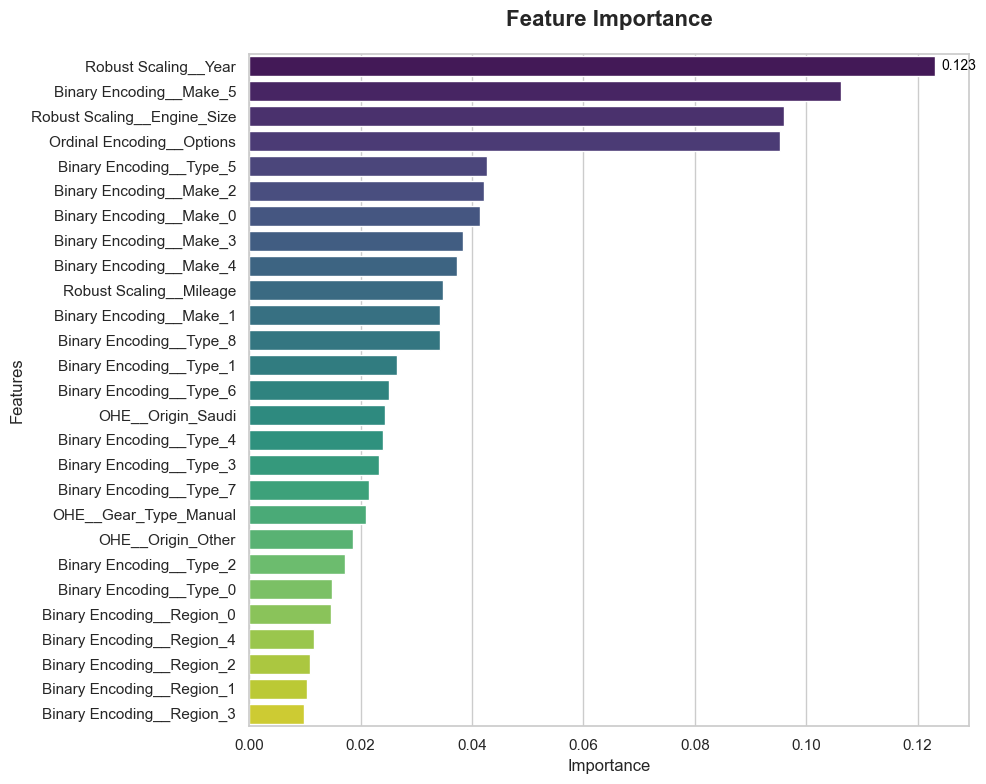

In [165]:
# Feature Importance Visualization

sns.set_style("whitegrid")
plt.figure(figsize=(10,8))

palette = sns.color_palette("viridis", n_colors=len(importance))

ax = sns.barplot(
    x="Importance",
    y="Feature",
    data=importance,
    palette=palette
)

ax.bar_label(
    ax.containers[0],
    fmt='%.3f',
    padding=5,
    fontsize=10,
    color='black'
)

ax.set_title("Feature Importance", fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel("Importance", fontsize=12)
ax.set_ylabel("Features", fontsize=12)

plt.tight_layout()
plt.show()

Based on the feature importance analysis:

* `Year` is the most significant feature influencing used car prices, followed by `Make` and `Engine_Size`.
* The car's production year is the most critical price determinant. The production year exhibits a highly robust price pattern, making it the primary factor utilized by the model.
* `Make` has the second most significant impact on used car prices.
* `Engine_Size` has the third most significant impact on used car prices.

## **Model Improvement**

Based on the model benchmarking analysis and references from various sources, further model improvements will be implemented to address the performance of the model, which is still considered weak based on references (MAPE > 20%). This will be achieved through feature generation by creating new features.

### **Feature Generation**

In this step, new features will be generated from the existing features.

#### **New Feature `Make_Tier`**

In [166]:
# unique values of the Make feature

df_model['Make'].unique()

array(['GMC', 'Land Rover', 'Kia', 'Mazda', 'Porsche', 'Hyundai',
       'Toyota', 'Chrysler', 'Lexus', 'Nissan', 'Mitsubishi', 'Ford',
       'MG', 'Chevrolet', 'Mercedes', 'Jeep', 'BMW', 'Lincoln', 'Genesis',
       'Honda', 'Zhengzhou', 'Dodge', 'HAVAL', 'Cadillac', 'Changan',
       'Aston Martin', 'Renault', 'Suzuki', 'Mercury', 'INFINITI', 'Audi',
       'Rolls-Royce', 'BYD', 'Volkswagen', 'Victory Auto', 'Geely',
       'Isuzu', 'Daihatsu', 'Maserati', 'Other', 'Hummer', 'GAC', 'Lifan',
       'Bentley', 'Chery', 'Jaguar', 'Peugeot', 'Foton', 'MINI', 'Skoda',
       'Fiat', 'Iveco', 'FAW', 'Great Wall', 'Ferrari'], dtype=object)

Add New Feature `Make_Tier`: The tier of the car company or brand 
> Why `Make_Tier`? When determining the value of a used car, its make and model play a significant role. A car's popularity depends on its features and quality. Therefore, most cars from leading brands are more popular and more expensive compared to cars without a well-known brand. Cars with high demand and limited supply also offer better resale value. 
> Reference: [Top 10 Factors Affecting the Price of a Second-hand Car](https://poonawallafincorp.com/blogs/pre-owned-car-loan/factors-affecting-on-price-of-second-hand-car)

---
The following are the categories for `Make_Tier`:

1. Ultra Luxury: Rolls-Royce, Bentley, Ferrari, Aston Martin, Maserati
2. Premium Luxury: Mercedes / Mercedes-Benz, BMW, Audi, Lexus, Porsche, Cadillac, Land Rover, Jaguar, INFINITI, Genesis, Lincoln
3. Midrange: Toyota, Honda, Mazda, Nissan, Hyundai, Kia, Mitsubishi, Ford, Chevrolet, Jeep, GMC, Dodge, MG, Peugeot, Volkswagen, Skoda, BYD, Isuzu, GAC, Great Wall, Haval
4. Entry Level: Chery, Geely, Daihatsu, Suzuki, Renault, Lifan, Changan, Zhengzhou, FAW, Iveco, Other, Chrysler, Mercury, Victory Auto, Hummer, Foton, MINI, Fiat, and Others (lesser-known brands)

In [167]:
# add new feature Make_Tier and define each with variables

tier_ultra_luxury = [
    'rolls-royce', 'bentley', 'ferrari', 'aston martin',
    'maserati', 'lamborghini'
]

tier_premium_luxury = [
    'mercedes', 'mercedes-benz', 'bmw', 'audi', 'lexus',
    'porsche', 'cadillac', 'land rover', 'jaguar', 'infiniti',
    'genesis', 'lincoln'
]

tier_midrange = [
    'toyota', 'honda', 'mazda', 'nissan', 'hyundai', 'kia',
    'mitsubishi', 'ford', 'chevrolet', 'jeep', 'gmc', 'dodge',
    'mg', 'peugeot', 'volkswagen', 'skoda', 'byd', 'isuzu',
    'gac', 'great wall', 'haval'
]

tier_entry = [
    'chery', 'geely', 'daihatsu', 'suzuki', 'renault', 'lifan',
    'changan', 'zhengzhou', 'faw', 'iveco', 'other'
]

# function to return brand tier
def make_tier(make):
    if pd.isna(make):
        return None

    make = make.strip().lower()

    if make in tier_ultra_luxury:
        return 'Ultra Luxury'
    elif make in tier_premium_luxury:
        return 'Premium Luxury'
    elif make in tier_midrange:
        return 'Midrange'
    else:
        return 'Entry Level'

# add new column and apply the result of the returned function
df_model['Make_Tier'] = df_model['Make'].apply(make_tier)

df_model.head()

,Type,Region,Make,Gear_Type,Origin,Options,Year,Engine_Size,Mileage,Price,Make_Tier
1,Yukon,Riyadh,GMC,Automatic,Saudi,Full,2014,8.0,80000,120000,Midrange
2,Range Rover,Riyadh,Land Rover,Automatic,Gulf Arabic,Full,2015,5.0,140000,260000,Premium Luxury
3,Optima,Hafar Al-Batin,Kia,Automatic,Saudi,Semi Full,2015,2.4,220000,42000,Midrange
5,CX3,Abha,Mazda,Automatic,Saudi,Semi Full,2019,2.0,25000,58000,Midrange
6,Cayenne S,Riyadh,Porsche,Automatic,Saudi,Full,2012,4.8,189000,85000,Premium Luxury


In [168]:
# check Make_Tier unique values

df_model['Make_Tier'].unique()

array(['Midrange', 'Premium Luxury', 'Entry Level', 'Ultra Luxury'],
      dtype=object)

#### **New Feature `Body_Type`**

In [169]:
# unique values of the Type feature

df_model['Type'].unique()

array(['Yukon', 'Range Rover', 'Optima', 'CX3', 'Cayenne S', 'Sonata',
       'Avalon', 'C300', 'Land Cruiser', 'LS', 'FJ', 'Tucson', 'Sunny',
       'Pajero', 'Azera', 'Focus', '5', 'Spark', 'Pathfinder', 'Accent',
       'ML', 'Corolla', 'Tahoe', 'A', 'Altima', 'Expedition', 'Senta fe',
       'Liberty', 'X', 'Land Cruiser Pickup', 'VTC', 'Malibu', 'The 5',
       'Patrol', 'Grand Cherokee', 'Camry', 'SL', 'Previa', 'MKZ',
       'Datsun', 'Hilux', 'GLC', 'Edge', '6', 'Innova', 'Navara', 'G80',
       'Carnival', 'Suburban', 'Camaro', 'Accord', 'Taurus', 'Elantra',
       'Flex', 'S', 'Cerato', 'Furniture', 'Murano', 'Land Cruiser 70',
       '3', 'Pick up', 'Charger', 'H6', 'Hiace', 'Fusion', 'Aveo', 'CX9',
       'Yaris', 'Sierra', 'Durango', 'CT-S', 'Sylvian Bus', 'ES',
       'Navigator', 'Opirus', 'The 7', 'Creta', 'CS35', 'The 3', 'GLE',
       'Sedona', 'Victoria', 'Prestige', 'CLA', 'Vanquish', 'Safrane',
       'Cores', 'Cadenza', "D'max", 'Silverado', 'Rio', 'Maxima',
     

Add New Feature `Body_Type`: Classification of `Type` based on the car's body shape/type. 
> Why `Body_Type`? Aside from the car type/model, certain car designs are more sought after by used car buyers than others. In recent years, tastes and preferences in buying used cars have shifted. People increasingly prefer to buy used SUVs to accommodate their family needs, as well as for safety and commercial purposes. Outdated models and cars are known to have lower resale prices. 
> Reference: [Top 10 Factors Affecting the Price of a Second-hand Car](https://poonawallafincorp.com/blogs/pre-owned-car-loan/factors-affecting-on-price-of-second-hand-car)

The following are the categories for `Body_Type`:

1. SUV: Yukon, Range Rover, CX3, Cayenne S, Land Cruiser, FJ, Tucson, Pajero, Pathfinder, ML, Tahoe, Expedition, Senta fe, Liberty, Patrol, Grand Cherokee, Murano, Land Cruiser 70, H6, CX9, Sierra, Durango, Navigator, Creta, CS35, GLE, Mohave, Explorer, Rush, Cherokee, X-Trail, Rav4, Trailblazer, Blazer, CX5, Acadia, H3, GS3, Duster, RX, Safari, Vitara, Kaptiva, Nativa, LF X60, Koleos, Pilot, Compass, X-Terra, KICKS, Montero, Touareg, Azkarra, GL, Macan, RX5, RX8, Tiguan, CS75, CS85, CS95, Q5, Q7, GX, X40, X7, HS, HRV, CRV, 4Runner, Defender, Discovery, Grand Vitara, Armada, Envoy
2. Sedan: Optima, Sonata, Avalon, C300, Sunny, Azera, 5, Accent, Corolla, Altima, Malibu, Camry, MKZ, The 3, Victoria, CLA, Safrane, Cadenza, Maxima, Cruze, Caprice, Grand Marquis, Impala, A6, IS, Fluence, Marquis, 6, Charger, Fusion, Elantra, Taurus, Accord, Avante, Passat, Optra, 300, A4, A5, CT4, CT5, CT6, S300, The 6
3. Hatchback: Spark, Focus, Aveo, Yaris, Rio, Veloster, Beetle, Picanto, A3 (hatch), Logan (hatch), Countryman, Emgrand (hatch)
4. Pickup: Land Cruiser Pickup, Hilux, D’max, Silverado, Navara, Vego, Gran Max Pickup, Colorado, D-MAX, L200, Ranger, Dyna, F150
5. Van: Hiace, H1, Van R, APV, Viano, Dokker, Coaster, Urvan, Sylvian Bus, Bus County, Mini Van, Town Car
6. Coupe / Sports / Performance: Camaro, Mustang, Challenger, DB9, Cayman, Coupe S, SL, Vanquish, GTB 599 Fiorano, F Type, 911
7. MPV: Previa, Innova, Carnival, Sedona, Carenz, Avanza, Odyssey, APV, Suvanna, Ertiga
8. Luxury / Premium: LS, The 5, G80, The 7, Prestige, ES, Opirus, GLC, The M, Genesis, CL, A7, A8, Quattroporte, Flying Spur, Panamera, Levante, Ghost
9. Truck / Bus: Sylvian Bus, Bus Urvan, Bus County, Dyna, Coaster, Daily
10. Other

In [170]:
# Add new feature Body_Type and define each with variables

body_type_map = {
    "SUV": [
        "Yukon", "Range Rover", "CX3", "Cayenne S", "Land Cruiser", "FJ", "Tucson", "Pajero", 
        "Pathfinder", "ML", "Tahoe", "Expedition", "Senta fe", "Liberty", "Patrol", "Grand Cherokee", 
        "Murano", "Land Cruiser 70", "H6", "CX9", "Sierra", "Durango", "Navigator", "Creta", 
        "CS35", "GLE", "Mohave", "Explorer", "Rush", "Cherokee", "X-Trail", "Rav4", "Trailblazer", 
        "Blazer", "CX5", "Acadia", "H3", "GS3", "Duster", "RX", "Safari", "Vitara", "Kaptiva", 
        "Nativa", "LF X60", "Koleos", "Pilot", "Compass", "X-Terra", "KICKS", "Montero", "Touareg", 
        "Azkarra", "GL", "Macan", "RX5", "RX8", "Tiguan", "CS75", "CS85", "CS95", "Q5", "Q7", 
        "GX", "X40", "X7", "HS", "HRV", "CRV", "4Runner", "Defender", "Discovery", "Grand Vitara", 
        "Armada", "Envoy"
    ],

    "Sedan": [
        "Optima", "Sonata", "Avalon", "C300", "Sunny", "Azera", "5", "Accent", "Corolla", "Altima", 
        "Malibu", "Camry", "MKZ", "The 3", "Victoria", "CLA", "Safrane", "Cadenza", "Maxima", 
        "Cruze", "Caprice", "Grand Marquis", "Impala", "A6", "IS", "Fluence", "Marquis", "6", 
        "Charger", "Fusion", "Elantra", "Taurus", "Accord", "Avante", "Passat", "Optra", "300", 
        "A4", "A5", "CT4", "CT5", "CT6", "S300", "The 6"
    ],

    "Hatchback": [
        "Spark", "Focus", "Aveo", "Yaris", "Rio", "Veloster", "Beetle", "Picanto", "A3", "Logan", 
        "Countryman", "Emgrand"
    ],

    "Pickup": [
        "Land Cruiser Pickup", "Hilux", "D'max", "Silverado", "Navara", "Vego", "Gran Max", 
        "Colorado", "D-MAX", "L200", "Ranger", "Dyna", "F150"
    ],

    "Van": [
        "Hiace", "H1", "Van R", "APV", "Viano", "Dokker", "Coaster", "Urvan", "Sylvian Bus", 
        "Bus County", "Mini Van", "Town Car"
    ],

    "Coupe/Sports": [
        "Camaro", "Mustang", "Challenger", "DB9", "Cayman", "Coupe S", "SL", "Vanquish", 
        "GTB 599 Fiorano", "F Type", "911"
    ],

    "MPV": [
        "Previa", "Innova", "Carnival", "Sedona", "Carenz", "Avanza", "Odyssey", "APV", 
        "Suvana", "Ertiga"
    ],

    "Luxury": [
        "LS", "The 5", "G80", "The 7", "Prestige", "ES", "Opirus", "GLC", "The M", "Genesis", 
        "CL", "A7", "A8", "Quattroporte", "Flying Spur", "Panamera", "Levante", "Ghost"
    ],

    "Truck/Bus": [
        "Sylvian Bus", "Bus Urvan", "Bus County", "Dyna", "Coaster", "Daily"
    ],

    "Other": [
        "A", "X", "VTC", "S", "Furniture", "Cores", "Z", "C", "Seven", "Delta", "Abeka", 
        "The 4", "The 6", "The 3", "Prestige Plus", "Copper", "Power", "2", "3", "5", "6"
    ]
}

# function to return car body type
def body_type(car_type):
    for category, models in body_type_map.items():
        if car_type in models:
            return category
    return "Other" 

# add new column and apply the result of the returned function
df_model["Body_Type"] = df_model["Type"].apply(body_type)

df_model["Body_Type"].value_counts()

Body_Type
Sedan           1251
SUV              989
Other            754
Pickup           208
Luxury           150
Hatchback        116
MPV               78
Van               67
Coupe/Sports      39
Truck/Bus          3
Name: count, dtype: int64

In [171]:
# rearrange column

reorder_cols = [
    'Type', 'Body_Type', 'Region', 'Make', 'Make_Tier', 'Gear_Type', 'Origin', 'Options',
    'Year', 'Engine_Size', 'Mileage', 'Price'
]

df_model = df_model[reorder_cols]

df_model.head()

,Type,Body_Type,Region,Make,Make_Tier,Gear_Type,Origin,Options,Year,Engine_Size,Mileage,Price
1,Yukon,SUV,Riyadh,GMC,Midrange,Automatic,Saudi,Full,2014,8.0,80000,120000
2,Range Rover,SUV,Riyadh,Land Rover,Premium Luxury,Automatic,Gulf Arabic,Full,2015,5.0,140000,260000
3,Optima,Sedan,Hafar Al-Batin,Kia,Midrange,Automatic,Saudi,Semi Full,2015,2.4,220000,42000
5,CX3,SUV,Abha,Mazda,Midrange,Automatic,Saudi,Semi Full,2019,2.0,25000,58000
6,Cayenne S,SUV,Riyadh,Porsche,Premium Luxury,Automatic,Saudi,Full,2012,4.8,189000,85000


### **Feature Selection (After Adding New Features)**

In [172]:
x = df_model.drop(['Price'], axis=1)
y = df_model['Price']

### **Split Train and Test Data**

Split the data, train set = 80% and test set = 20%.

In [173]:
xtrain, xtest, ytrain, ytest = train_test_split(
    x, 
    y, 
    test_size= 0.2, 
    random_state=42
)

### **Preprocessing Scheme (After Adding New Features)**

**Encoding**: In order to utilize all selected features, categorical features must be converted into numerical features. Column Transformer will be used to transform these data types so they can be integrated into the model pipeline.

**1. Binary Encoding**: suitable for categorical features with **more than five categories**.
* **Features**: `Type`, `Make`, `Body_Type`, `Region`

**2. One Hot Encoding**: suitable for categorical features with **five or fewer categories** and **no inherent order or hierarchy** among categories.
* **Features**: `Gear_Type`, `Origin`

**3. Ordinal Encoding**: suitable for categorical features with **five or fewer categories** that have a **ranking or hierarchy**.
* **Features**: `Options` that represents car feature completeness level:
    - **Full**: 3
    - **Semi Full**: 2
    - **Standard**: 1

* and `Make_Tier` that represents car brand tier or car luxury level:
    - **Ultra Luxury**: 4
    - **Premium Luxury**: 3
    - **Midrange**: 2
    - **Entry Level**: 1

**Robust Scaling**: Robust Scaler standardizes numerical features using the **median** and **Interquartile Range (IQR)**, making it particularly suitable for datasets containing a significant number of outliers.

* **Features**: `Year`, `Engine_Size`, `Mileage`

In [174]:
# Unique Values in Categorical Features

categoric_features = ['Type', 'Body_Type', 'Region', 'Make', 'Make_Tier', 'Gear_Type', 'Origin', 'Options']

for col in categoric_features:
    print(f"Unique Values in {col} feature : {df_model[col].nunique()}")

Unique Values in Type feature : 311
Unique Values in Body_Type feature : 10
Unique Values in Region feature : 27
Unique Values in Make feature : 55
Unique Values in Make_Tier feature : 4
Unique Values in Gear_Type feature : 2
Unique Values in Origin feature : 3
Unique Values in Options feature : 3


In [175]:
# ordinal encoding mapping

ord = [
    {
        'col': 'Options',
        'mapping': {None: 0, "Standard": 1, "Semi Full": 2, "Full": 3}
    },
    {
        'col': 'Make_Tier',
        'mapping': {None: 0, 'Entry Level': 1, 'Midrange': 2, 'Premium Luxury': 3, 'Ultra Luxury' : 4}
    }
]

oe = OrdinalEncoder(cols=['Options', 'Make_Tier'], mapping=ord)

In [176]:
# Preprocessing by ColumnTransformer

preproces = ColumnTransformer([
    ('Binary Encoding', BinaryEncoder(), ['Type', 'Region', 'Make', 'Body_Type']),
    ('OHE', OneHotEncoder(drop='first'), ['Origin', 'Gear_Type']),
    ('Ordinal Encoding', oe, ['Options', 'Make_Tier']),
    ('Robust Scaling', RobustScaler(), ['Year', 'Engine_Size', 'Mileage']),
], remainder='passthrough')

preproces

,transformers,"[('Binary Encoding', ...), ('OHE', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True
,force_int_remainder_cols,'deprecated'
,verbose,0
,cols,None
,mapping,None


## **Model Benchmarking (After Generating New Features)**

In [177]:
# Models
lr = LinearRegression() 
knn = KNeighborsRegressor() 
dt = DecisionTreeRegressor(random_state=42)
svm = SVR()  
rf = RandomForestRegressor(random_state=42)
abr = AdaBoostRegressor(random_state=42) 
gb = GradientBoostingRegressor(random_state=42) 
xgb = XGBRegressor(random_state=42)

models = [lr, knn, dt, svm, rf, abr, gb, xgb]

# Modeling is performed on a logarithmic scale, but then inversed back for interpretation.
log_lr = TransformedTargetRegressor(lr, func=np.log, inverse_func=np.exp)
log_knn = TransformedTargetRegressor(knn, func=np.log, inverse_func=np.exp)
log_dt = TransformedTargetRegressor(dt, func=np.log, inverse_func=np.exp)
log_svm = TransformedTargetRegressor(svm, func=np.log, inverse_func=np.exp)
log_rf = TransformedTargetRegressor(rf, func=np.log, inverse_func=np.exp)
log_abr = TransformedTargetRegressor(abr, func=np.log, inverse_func=np.exp)
log_gb = TransformedTargetRegressor(gb, func=np.log, inverse_func=np.exp)
log_xgb = TransformedTargetRegressor(xgb, func=np.log, inverse_func=np.exp)

models_log = [log_lr, log_knn, log_dt, log_svm, log_rf, log_abr, log_gb, log_xgb]

In [178]:
# Benchmarking Baseline Models (Train Data)

avg_mape = []
std_mape = []

avg_mae = []
std_mae = []

for model in models_log:
    pipe_model = Pipeline([
        ('prepros', preproces),
        ('model', model)
    ])

    score_mape = cross_val_score(
        pipe_model, 
        xtrain, 
        ytrain, 
        cv=crossval,
        scoring='neg_mean_absolute_percentage_error',
        error_score = 'raise',
        n_jobs = -1
    )

    score_mae = cross_val_score(
        pipe_model, 
        xtrain, 
        ytrain, 
        cv=crossval,
        scoring='neg_mean_absolute_error',
        error_score = 'raise',
        n_jobs = -1
    )

    # MAPE
    avg_mape.append(-score_mape.mean()) 
    std_mape.append(score_mape.std())

    # MAE
    avg_mae.append(-score_mae.mean()) 
    std_mae.append(score_mae.std())

# benchmark summary
summary = pd.DataFrame({
    'Model': [
        'Linear Regression',
        'K-Nearest Neighbor',
        'Decision Tree',
        'Support Vector Machine',
        'Random Forest',
        'Adaptive Boosting',
        'Gradient Boosting',
        'Xtreme Gradient Boosting'
    ],
    'avg_MAPE': avg_mape,
    'std_MAPE': std_mape,
    'avg_MAE': avg_mae,
    'std_MAE': std_mae
}).sort_values(by='avg_MAPE').reset_index(drop = True)

summary

,Model,avg_MAPE,std_MAPE,avg_MAE,std_MAE
0,Support Vector Machine,0.183146,0.004865,13274.994208,610.352186
1,Xtreme Gradient Boosting,0.194535,0.003074,14122.278516,616.088754
2,Random Forest,0.197725,0.005433,14300.010835,528.064645
3,Gradient Boosting,0.211901,0.006773,15812.207069,1190.817053
4,K-Nearest Neighbor,0.279653,0.012046,17575.426926,816.171334
5,Linear Regression,0.280529,0.011391,20186.380986,1011.625266
6,Decision Tree,0.287108,0.011050,20098.019822,757.536612
7,Adaptive Boosting,0.316829,0.013751,23373.053659,1517.789061


Based on the table above, the **training MAPE and MAE values** for each model can be observed. Among all models, **Support Vector Machine (SVM)** achieves the best performance on the training dataset, as indicated by its lowest prediction error compared to the other models.

#### **Predict to Test Set with the Benchmark Model**

In [179]:
# Models Performance Evaluation 

models_comp = {
    'Linear Regression': lr,
    'K-Nearest Neighbor': knn,
    'Decision Tree': dt,
    'Support Vector Machine': svm,
    'Random Forest': rf,
    'Adaptive Boosting': abr,
    'Gradient Boosting': gb,
    'Xtreme Gradient Boosting': xgb
}

score_mape = []
score_mae = []
model_names = []

for model_name, model in models_comp.items():

    pipe_model = Pipeline([
        ('preprocessing', preproces),
        ('model', model) 
    ])

    # fit to train set
    pipe_model.fit(xtrain, ytrain)

    # predict test set
    y_pred = pipe_model.predict(xtest)

    score_mape.append(mean_absolute_percentage_error(ytest, y_pred))
    score_mae.append(mean_absolute_error(ytest, y_pred))
    model_names.append(model_name)

score_before_tuning = pd.DataFrame({
    'Model' : model_names,
    'MAPE': score_mape,
    'MAE': score_mae
}, index=models_comp.keys())

score_before_tuning.sort_values('MAPE').reset_index(drop = True)


,Model,MAPE,MAE
0,Xtreme Gradient Boosting,0.212081,13076.559570
1,Random Forest,0.229336,14337.062343
2,Gradient Boosting,0.266989,16863.706842
3,Decision Tree,0.288679,18812.142271
4,K-Nearest Neighbor,0.308105,17946.821067
5,Linear Regression,0.551702,27445.075883
6,Support Vector Machine,0.676747,41543.448759
7,Adaptive Boosting,0.917095,40083.293187


However, when evaluated on the test set, the SVM model showing signs of underfitting.

In [180]:
# Model Benchmarking Baseline (Train and Test Data)

model_names = []

cv_train_mape = []
cv_train_mae = []

test_mape = []
test_mae = []

for model in models:
    pipeline = Pipeline([
        ('preprocessing', preproces),
        ('model', model)
    ])

    # cross validation data train
    score_mape = cross_val_score(
        pipeline, 
        xtrain, 
        ytrain,
        scoring='neg_mean_absolute_percentage_error',
        cv=crossval, 
        n_jobs=-1
    )
    score_mae = cross_val_score(
        pipeline, 
        xtrain, 
        ytrain,
        scoring='neg_mean_absolute_error',
        cv=crossval, 
        n_jobs=-1
    )

    # MAPE and MAE Train
    cv_train_mape.append(-score_mape.mean())
    cv_train_mae.append(-score_mae.mean())

    # fit to train set
    pipeline.fit(xtrain, ytrain)

    # predict to test set
    y_pred = pipeline.predict(xtest)

    # MAPE and MAE Test
    test_mape.append(mean_absolute_percentage_error(ytest, y_pred))
    test_mae.append(mean_absolute_error(ytest, y_pred))


# Benchmarking Baseline Models
summary_benchmark = pd.DataFrame({
        'Model': [
        'Linear Regression',
        'K-Nearest Neighbor',
        'Decision Tree',
        'Support Vector Machine',
        'Random Forest',
        'Adaptive Boosting',
        'Gradient Boosting',
        'Xtreme Gradient Boosting'
    ],
    'Train MAPE': cv_train_mape,
    'Test MAPE': test_mape,
    'Train MAE': cv_train_mae,
    'Test MAE': test_mae
})

# Add MAPE Difference
summary_benchmark['MAPE Difference'] = summary_benchmark['Train MAPE'] - summary_benchmark['Test MAPE']

# Sort Column in Summary
summary_benchmark = summary_benchmark[
    ['Model', 'Train MAPE', 'Test MAPE', 'MAPE Difference', 'Train MAE', 'Test MAE']
]

# Sorting Models by Test MAPE
summary_benchmark = summary_benchmark.sort_values(by='Test MAPE').reset_index(drop = True)

summary_benchmark


,Model,Train MAPE,Test MAPE,MAPE Difference,Train MAE,Test MAE
0,Xtreme Gradient Boosting,0.217629,0.212081,0.005548,14296.873828,13076.559570
1,Random Forest,0.228379,0.229336,-0.000957,14904.859706,14337.062343
2,Gradient Boosting,0.255710,0.266989,-0.011279,17037.954794,16863.706842
3,Decision Tree,0.308845,0.288679,0.020166,20767.050402,18812.142271
4,K-Nearest Neighbor,0.311693,0.308105,0.003588,18165.936357,17946.821067
5,Linear Regression,0.560924,0.551702,0.009222,28154.029024,27445.075883
6,Support Vector Machine,0.683235,0.676747,0.006489,43174.733655,41543.448759
7,Adaptive Boosting,0.868549,0.917095,-0.048546,38307.402711,40083.293187


Based on the benchmarking table of MAPE values for the train and test data above:

* After incorporating the new features, there is a clear improvement in model performance, indicated by the decrease in Train MAPE from 0.241587 (24.16%) to (21.76%) and Test MAPE from 0.229336 (22.21%) to 0.212081% (21.20%).
* The Random Forest, Gradient Boosting, and Adaptive Boosting models show slight overfitting.
* The DT, KNN, Linear Regression, SVM, and Adaptive Boosting models are underfitting.
* The MAPE difference for the XGBoost model is ~0.55%, and for Random Forest, it is ~0.095%. Both models can still be considered fairly stable and good at generalization.

> **Top 2 Models from Model Benchmarking (After Generating New Features): Xtreme Gradient Boosting and Random Forest**

## **Hyperparameter Tuning**

#### **1. Hyperparameter Tuning XGBoost**

In [181]:
# Hyperparameter Tuning XGBoost

pipeline_xgb = Pipeline([
    ('preprocessing', preproces),
    ('model', xgb)
])

param_tuning_xgb = {
    'model__learning_rate': [0.05, 0.1],
    'model__n_estimators': [300, 500],
    'model__max_depth': [5, 7],   
    'model__min_child_weight': [1, 2], 
    'model__subsample': [0.7, 0.8],    
    'model__colsample_bytree': [0.7, 0.8],
    'model__gamma': [0, 0.1],           
    'model__reg_lambda': [5, 10],        
    'model__reg_alpha': [0.1, 0.5]
}
 

grid_xgb = GridSearchCV(
    estimator=pipeline_xgb,
    param_grid=param_tuning_xgb,
    scoring=['neg_mean_absolute_error', 'neg_mean_absolute_percentage_error'], 
    cv=crossval,
    n_jobs=-1,
    verbose=2,
    refit='neg_mean_absolute_percentage_error'
)

# Print progress
print("Starting XGBoost Hyperparameter Tuning... Please wait.\n")

grid_xgb.fit(xtrain, ytrain)

Starting XGBoost Hyperparameter Tuning... Please wait.

Fitting 5 folds for each of 512 candidates, totalling 2560 fits


,estimator,"Pipeline(step...=None, ...))])"
,param_grid,"{'model__colsample_bytree': [0.7, 0.8], 'model__gamma': [0, 0.1], 'model__learning_rate': [0.05, 0.1], 'model__max_depth': [5, 7], ...}"
,scoring,"['neg_mean_absolute_error', 'neg_mean_absolute_percentage_error']"
,n_jobs,-1
,refit,'neg_mean_absolute_percentage_error'
,cv,KFold(n_split... shuffle=True)
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('Binary Encoding', ...), ('OHE', ...), ...]"


In [182]:
# Check best score dan best parameters XGBoost

print(f'Best Parameters XGBoost: {grid_xgb.best_params_}')

print(f'\nBest MAPE Score: {-grid_xgb.best_score_}')

Best Parameters XGBoost: {'model__colsample_bytree': 0.8, 'model__gamma': 0, 'model__learning_rate': 0.05, 'model__max_depth': 7, 'model__min_child_weight': 2, 'model__n_estimators': 500, 'model__reg_alpha': 0.1, 'model__reg_lambda': 10, 'model__subsample': 0.8}

Best MAPE Score: 0.19733991026878356


#### **2. Hyperparameter Tuning Random Forest**

In [183]:
# Hyperparameter Tuning Random Forest

# pipeline
pipeline_rf = Pipeline([
    ('preprocessing', preproces),
    ('model', rf)
])

# parameters
param_tuning_rf = {
    'model__n_estimators': [200, 300, 400], 
    'model__max_depth': [10, 15],   
    'model__min_samples_split': [3, 4],
    'model__min_samples_leaf': [2, 3],   
    'model__max_features': ['sqrt', 'log2', 0.6, 0.7],
    'model__bootstrap': [True, False]
}

# grid search cross validation 
grid_rf = GridSearchCV(
    estimator=pipeline_rf,
    param_grid=param_tuning_rf,
    cv=crossval,
    scoring={
        'MAE': 'neg_mean_absolute_error',
        'MAPE': 'neg_mean_absolute_percentage_error'
    },
    n_jobs=-1,
    verbose=2,
    refit='MAPE'   
)

# Print progress
print("Starting Random Forest Hyperparameter Tuning... Please wait.\n")

grid_rf.fit(xtrain, ytrain)

Starting Random Forest Hyperparameter Tuning... Please wait.

Fitting 5 folds for each of 192 candidates, totalling 960 fits


,estimator,Pipeline(step...m_state=42))])
,param_grid,"{'model__bootstrap': [True, False], 'model__max_depth': [10, 15], 'model__max_features': ['sqrt', 'log2', ...], 'model__min_samples_leaf': [2, 3], ...}"
,scoring,"{'MAE': 'neg_mean_absolute_error', 'MAPE': 'neg_mean_absolute_percentage_error'}"
,n_jobs,-1
,refit,'MAPE'
,cv,KFold(n_split... shuffle=True)
,verbose,2
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,transformers,"[('Binary Encoding', ...), ('OHE', ...), ...]"


In [184]:
# Check best score dan best parameters Random Forest

print(f'Best Parameters Random Forest: {grid_rf.best_params_}')

print(f'\nBest MAPE Score: {-grid_rf.best_score_}')

Best Parameters Random Forest: {'model__bootstrap': False, 'model__max_depth': 15, 'model__max_features': 0.6, 'model__min_samples_leaf': 2, 'model__min_samples_split': 3, 'model__n_estimators': 400}

Best MAPE Score: 0.21807570207522894


#### **Predict to Test Set with the Tuned Model**

In [185]:
# Get the best estimator for XGBoost and Random Forest

xgb_tuning = grid_xgb.best_estimator_
rf_tuning = grid_rf.best_estimator_ 

In [186]:
models = {
    "Xtreme Gradient Boosting Tuned": xgb_tuning, # pipeline with best estimator
    "Random Forest Tuned": rf_tuning # pipeline with best estimator
}

results = []

for model_names, model in models.items():

    # Fit model
    model.fit(xtrain, ytrain)
    
    # Predict test
    y_pred = model.predict(xtest)
    
    # Metrics evaluation
    mae  = mean_absolute_error(ytest, y_pred)
    mape = mean_absolute_percentage_error(ytest, y_pred)
    
    results.append({
        "Model": model_names,
        "MAPE": mape,
        "MAE": mae
    })

# Summary
score_after_tuning = pd.DataFrame(results).sort_values(by="MAPE").reset_index(drop = True)
score_after_tuning

,Model,MAPE,MAE
0,Xtreme Gradient Boosting Tuned,0.190793,11832.232422
1,Random Forest Tuned,0.211703,13282.933266


## **Models Performance Comparison (Final Best Model Selection)**

### **Models Performance Comparison Before and After Hyperparameter Tuning**

In [187]:
# Before hyperparameter tuning

print('Before Hyperparameter Tuning :')
display(score_before_tuning[score_before_tuning['Model'].isin(["Xtreme Gradient Boosting", "Random Forest"])])

# After hyperparameter tuning

print('After Hyperparameter tuning :')
display(score_after_tuning)

Before Hyperparameter Tuning :


,Model,MAPE,MAE
Random Forest,Random Forest,0.229336,14337.062343
Xtreme Gradient Boosting,Xtreme Gradient Boosting,0.212081,13076.559570


After Hyperparameter tuning :


,Model,MAPE,MAE
0,Xtreme Gradient Boosting Tuned,0.190793,11832.232422
1,Random Forest Tuned,0.211703,13282.933266


Results:

| Model | MAPE Before | MAPE After | MAE Before | MAE After |
| --- | --- | --- | --- | --- |
| **XGBoost** | 21.21% | 19.08% | 13,076.56 | 11,832.23 |
| **Random Forest** | 22.93% | 21.17% | 14,337.06 | 13,282.93 |

After performing hyperparameter tuning, based on the model performance comparison above, both the **XGBoost** and **Random Forest** models experienced an improvement in performance, as indicated by the decrease in their respective MAPE and MAE values.

In [188]:
# Get the model with best estimator without preprocessing from the pipeline for XGBoost and Random Forest

xgb_tuned = xgb_tuning.named_steps['model']
rf_tuned = rf_tuning.named_steps['model'] 

In [189]:
final_models_comp = {
    # Baseline Models
    'Linear Regression': lr,
    'K-Nearest Neighbors': knn,
    'Decision Tree': dt,
    'Support Vector Machine': svm,
    'Random Forest': rf,
    'Adaptive Boosting': abr,
    'Gradient Boosting': gb,
    'Xtreme Gradient Boosting': xgb,
    # Tuned Models
    'Xtreme Gradient Boosting Tuned': xgb_tuned, # model with best estimator but without preprocessing
    'Random Forest Tuned': rf_tuned # model with best estimator but without preprocessing
}

In [190]:
model_names = []
cv_train_mape = []
cv_train_mae = []
test_mape = []
test_mae = []

for names, model in final_models_comp.items():
    model_names.append(names)
    
    pipeline = Pipeline([
        ('preprocessing', preproces),
        ('model', model)
    ])
    
    # Cross-validation Train
    score_mape = cross_val_score(
        pipeline, 
        xtrain, 
        ytrain,
        scoring='neg_mean_absolute_percentage_error',
        cv=crossval, 
        n_jobs=-1
    )
    score_mae = cross_val_score(
        pipeline, 
        xtrain, 
        ytrain,
        scoring='neg_mean_absolute_error',
        cv=crossval, 
        n_jobs=-1
    )
    
    # metrics evaluation
    cv_train_mape.append(-score_mape.mean())
    cv_train_mae.append(-score_mae.mean())
    
    pipeline.fit(xtrain, ytrain)

    # Test
    y_pred = pipeline.predict(xtest)

    # metrics evaluation
    test_mape.append(mean_absolute_percentage_error(ytest, y_pred))
    test_mae.append(mean_absolute_error(ytest, y_pred))

# Summary final benchmark
final_benchmark = pd.DataFrame({
    'Model': model_names,
    'Train MAPE': cv_train_mape,
    'Test MAPE': test_mape,
    'Train MAE': cv_train_mae,
    'Test MAE': test_mae
})

# Add MAPE Difference
final_benchmark['MAPE Difference'] = final_benchmark['Train MAPE'] - final_benchmark['Test MAPE']

# Sorting column
final_benchmark = final_benchmark[
    ['Model', 'Train MAPE', 'Test MAPE', 'MAPE Difference', 'Train MAE', 'Test MAE']
]
# Sort Models by Test MAPE in Summary
final_benchmark = final_benchmark.sort_values(by = 'Test MAPE').reset_index(drop = True)
final_benchmark

,Model,Train MAPE,Test MAPE,MAPE Difference,Train MAE,Test MAE
0,Xtreme Gradient Boosting Tuned,0.197340,0.190793,0.006547,13291.922656,11832.232422
1,Random Forest Tuned,0.218076,0.211703,0.006373,14245.882060,13282.933266
2,Xtreme Gradient Boosting,0.217629,0.212081,0.005548,14296.873828,13076.559570
3,Random Forest,0.228379,0.229336,-0.000957,14904.859706,14337.062343
4,Gradient Boosting,0.255710,0.266989,-0.011279,17037.954794,16863.706842
5,Decision Tree,0.308845,0.288679,0.020166,20767.050402,18812.142271
6,K-Nearest Neighbors,0.311693,0.308105,0.003588,18165.936357,17946.821067
7,Linear Regression,0.560924,0.551702,0.009222,28154.029024,27445.075883
8,Support Vector Machine,0.683235,0.676747,0.006489,43174.733655,41543.448759
9,Adaptive Boosting,0.868549,0.917095,-0.048546,38307.402711,40083.293187


After performing hyperparameter tuning on the Top 2 Models and evaluating them on the test data, the final benchmarking results for the tuned and baseline models show that the best-performing model—based on having the lowest MAPE and MAE values—is the **XGB Regressor Tuned**.

* **Train MAPE** = 0.197340 (~19.73%)
* **Test MAPE** = 0.190793 (~19%)
* **MAPE Difference** = 0.006547 (~0.65%); a low MAPE difference indicates that the model's performance is stable across both train and test data, demonstrating that the model generalizes well to new data.
* **Train MAE** = 13291.922656
* **Test MAE** = 11832.232422

By using the XGBoost algorithm, the average prediction will deviate by approximately ~19% from the actual price, which is around 11,832 SAR off from its actual price.

> #### **Final Best Model = Xtreme Gradient Boosting Regressor Tuned**

In [191]:
# best model pipeline

best_model = grid_xgb.best_estimator_

best_model

,steps,"[('preprocessing', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('Binary Encoding', ...), ('OHE', ...), ...]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


### **XGBoost Model and The Algorithm Working Mechanism**

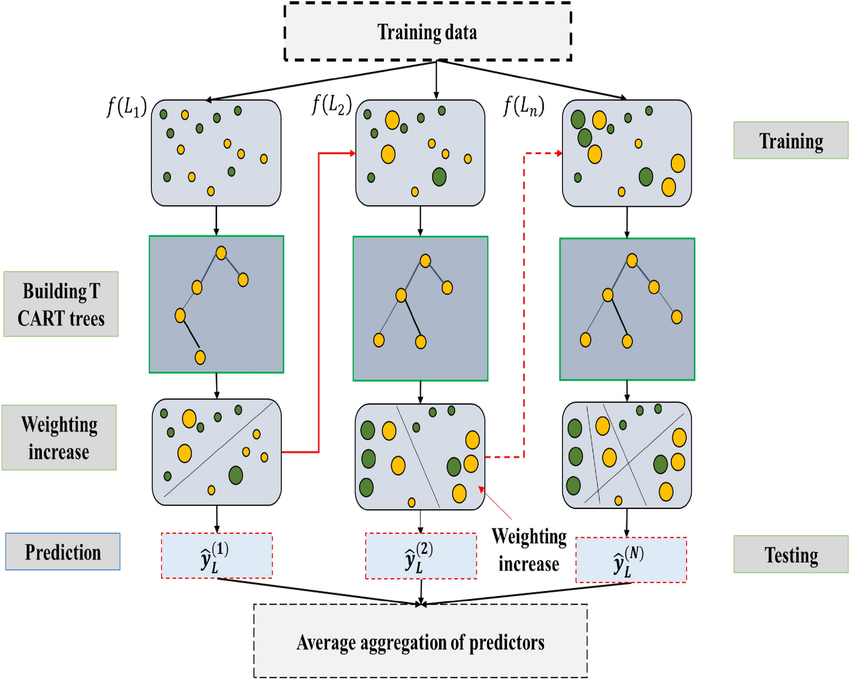

Source: Ali, Z.H. and Burhan, A.M. 2023. Hybrid machine learning approach for construction cost estimation: an evaluation of extreme gradient boosting model. Asian Journal of Civil Engineering. [Source](https://www.researchgate.net/journal/Asian-Journal-of-Civil-Engineering-2522-011X?_tp=eyJjb250ZXh0Ijp7ImZpcnN0UGFnZSI6InB1YmxpY2F0aW9uIiwicGFnZSI6InB1YmxpY2F0aW9uIiwicHJldmlvdXNQYWdlIjoiX2RpcmVjdCJ9fQ)

XGBoost is a boosting algorithm that is extremely accurate, and effective for handling large and complex datasets. XGBoost can model complex non-linear relationships, offers many tuning options to optimize performance, and provides easily interpretable feature importance. It is stable, reliable, and widely used in industry. Its combination of efficiency, stability, and high accuracy makes XGBoost one of the best algorithms for building machine learning model.

**XGBoost** works by:
1. Start with the training data <br>
The model begins with the dataset (features + target).

2. Build the first tree (f(L₁)) <br>
A first tree is trained to predict the target values.

3. Calculate errors <br>
After the first tree predicts, the models will check which samples are predicted poorly and compute the gradients (how wrong) and Hessians (how confident the model is).

4. Increase the weight of high-error samples <br>
Points with larger errors get more influence (heavier weight). These points become “more important” for the next tree.

5. Build the second tree (f(L₂)) and focusing on high-error points <br>
The new tree tries to fix the remaining errors from the previous tree.
Because weights changed, the tree naturally splits differently.

6. Update predictions again <br>
Combine Tree 1 + Tree 2 predictions (with a learning rate).

7. Repeat the process for many trees (f(Lₙ)) <br>
Each new tree is built on the updated residuals and updated weights. The red arrows in the diagram represent this boosting loop.

8. In testing, each tree makes a prediction <br>
The model applies all trained trees to the new data.

9. Final prediction = average/weighted sum of all trees <br>
All tree outputs are aggregated to produce the final prediction.

**Conclusion of How XGBoost Works**:
1. Train the first tree on the training data.
2. Measure errors and increase weight for samples with large errors.
3. Train the next tree that focuses more on these samples with large errors.
4. Add the new tree’s prediction to the previous prediction.
5. Repeat the process for many trees.
6. Final prediction is the combined output of all trees.

#### **Feature Importance**

In [192]:
# Get Features Name from Processing
feature_names = xgb_tuning.named_steps['preprocessing'].get_feature_names_out()

importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': xgb_tuned.feature_importances_
}).sort_values(by='Importance', ascending=False).reset_index()

importance

,index,Feature,Importance
0,28,Ordinal Encoding__Make_Tier,0.439974
1,29,Robust Scaling__Year,0.104484
2,30,Robust Scaling__Engine_Size,0.049788
3,27,Ordinal Encoding__Options,0.037632
4,19,Binary Encoding__Make_5,0.031635
5,1,Binary Encoding__Type_1,0.030292
6,21,Binary Encoding__Body_Type_1,0.028115
7,5,Binary Encoding__Type_5,0.021900
8,22,Binary Encoding__Body_Type_2,0.019033
9,23,Binary Encoding__Body_Type_3,0.018354


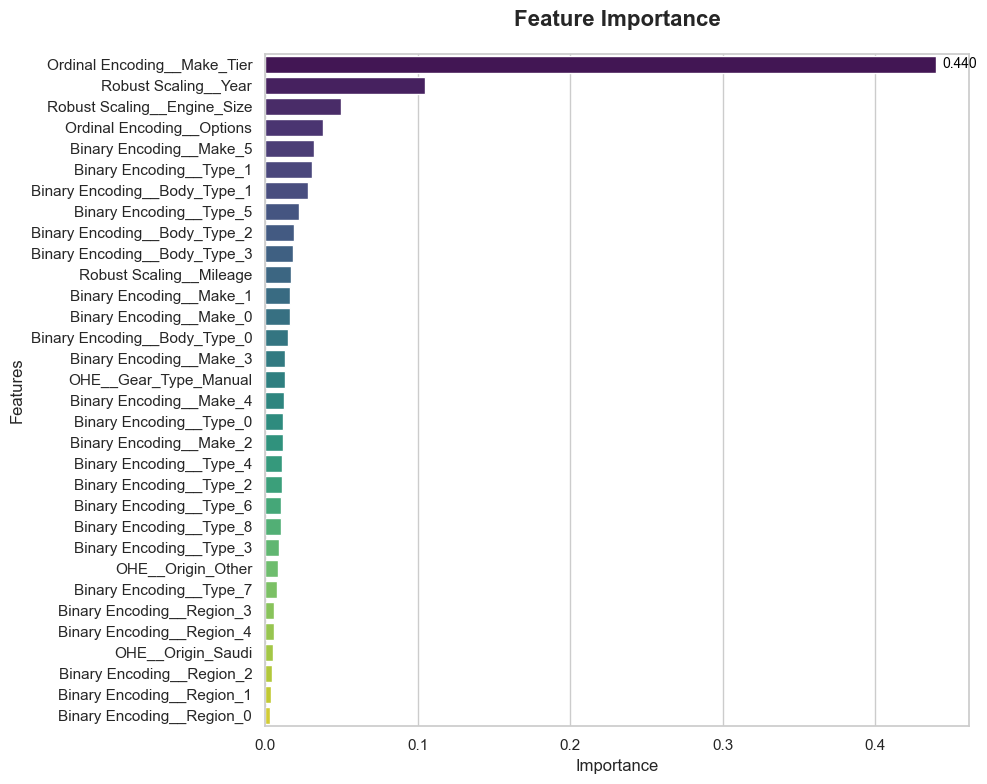

In [193]:
# Feature Importance Visualization

sns.set_style("whitegrid")
plt.figure(figsize=(10,8))

palette = sns.color_palette("viridis", n_colors=len(importance))

ax = sns.barplot(
    x="Importance",
    y="Feature",
    data=importance,
    palette=palette
)

ax.bar_label(
    ax.containers[0],
    fmt='%.3f',
    padding=5,
    fontsize=10,
    color='black'
)

ax.set_title("Feature Importance", fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel("Importance", fontsize=12)
ax.set_ylabel("Features", fontsize=12)

plt.tight_layout()
plt.show()


Based on the feature importance analysis:
- Make_Tier is the most significant feature influencing used car prices. The car brand's tier is the most critical price determinant. Cars within specific brand tiers exhibit highly robust price patterns, making it the primary factor utilized by the model.

### **Model Limitations**

* `Year` (Production year): 1998 – 2021
* `Engine_Size` (Engine capacity): 1.0 – 9.0
* `Mileage` (Mileage): 100 – 584,744 KM
* `Price` (Price): 5,000 – 600,000 SAR
* `Type` (Type): Car models/types sold in Saudi Arabia.
* `Region` (Sales region): 27 sales regions across Saudi Arabia.
* `Body_Type` (Body type/shape): SUV, Sedan, Luxury, Hatchback, Pickup, Coupe/Sports, MPV, Van, Truck/Bus, and others.
* `Make` (Brand): 55 car brands sold in the Saudi Arabian used car market.
* `Make_Tier` (Brand Tier): Ultra Luxury, Premium Luxury, Midrange, and Entry Level.
* `Gear_Type` (Transmission): Automatic and Manual.
* `Options` (Used cars equipment/feature completeness): Full, Semi Full, Standard.
* `Origin` (Car Origin): Gulf Arabic, Saudi, and others.

In [194]:
# Model Limitations

df_model

,Type,Body_Type,Region,Make,Make_Tier,Gear_Type,Origin,Options,Year,Engine_Size,Mileage,Price
1,Yukon,SUV,Riyadh,GMC,Midrange,Automatic,Saudi,Full,2014,8.0,80000,120000
2,Range Rover,SUV,Riyadh,Land Rover,Premium Luxury,Automatic,Gulf Arabic,Full,2015,5.0,140000,260000
3,Optima,Sedan,Hafar Al-Batin,Kia,Midrange,Automatic,Saudi,Semi Full,2015,2.4,220000,42000
5,CX3,SUV,Abha,Mazda,Midrange,Automatic,Saudi,Semi Full,2019,2.0,25000,58000
6,Cayenne S,SUV,Riyadh,Porsche,Premium Luxury,Automatic,Saudi,Full,2012,4.8,189000,85000
...,...,...,...,...,...,...,...,...,...,...,...,...
5616,CX9,SUV,Qassim,Mazda,Midrange,Automatic,Saudi,Full,2020,2.0,9500,132000
5618,Suburban,Other,Riyadh,GMC,Midrange,Automatic,Saudi,Full,2006,5.3,86000,50000
5619,X-Trail,SUV,Jeddah,Nissan,Midrange,Automatic,Saudi,Standard,2018,2.5,78794,68000
5621,Yukon,SUV,Dammam,GMC,Midrange,Automatic,Saudi,Full,2016,5.3,48000,145000


In [195]:
# Model Limitations (Statistics Description)

display(df_model.describe(), df_model.describe(include='object'))

,Year,Engine_Size,Mileage,Price
count,3655.000000,3655.000000,3655.000000,3655.000000
mean,2015.225718,3.178577,126428.611218,79710.701231
std,3.983298,1.460008,104657.752663,69188.122385
min,1998.000000,1.000000,100.000000,5000.000000
25%,2014.000000,2.000000,49513.000000,37250.000000
50%,2016.000000,2.700000,103885.000000,60000.000000
75%,2018.000000,4.000000,180000.000000,95000.000000
max,2021.000000,9.000000,573000.000000,599000.000000


,Type,Body_Type,Region,Make,Make_Tier,Gear_Type,Origin,Options
count,3655,3655,3655,3655,3655,3655,3655,3655
unique,311,10,27,55,4,2,3,3
top,Accent,Sedan,Riyadh,Toyota,Midrange,Automatic,Saudi,Full
freq,146,1251,1568,843,2939,3291,2783,1406


# **5. Analysis**

## **Actual Price vs Predicted Price Analysis**

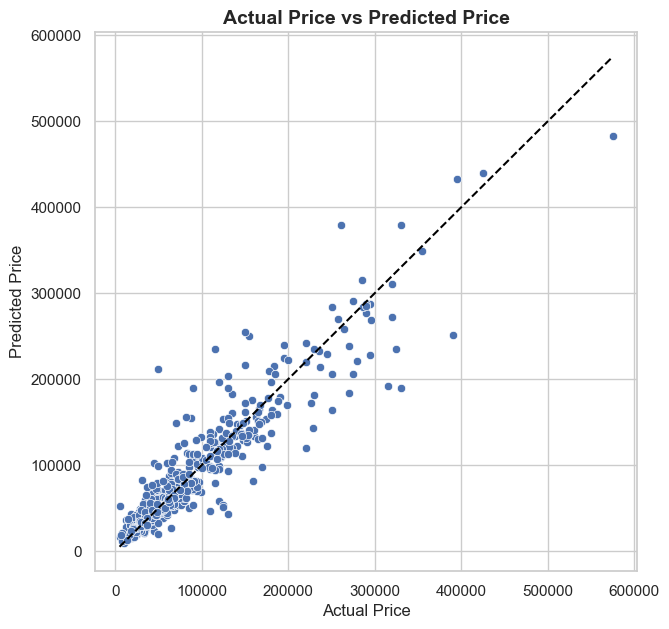

In [196]:
# Actual Price vs Prediction Price visualization

plt.figure(figsize=(7, 7))

# Scatter plot
sns.scatterplot(
    x=ytest,
    y=y_pred
)

# perfect prediction line plot
min_val = min(ytest.min(), y_pred.min())
max_val = max(ytest.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color='black', linestyle='--')

plt.title('Actual Price vs Predicted Price', fontsize=14, fontweight='bold')
plt.xlabel('Actual Price', fontsize=12)
plt.ylabel('Predicted Price', fontsize=12)

plt.show()


Based on the plot above:

* The data points are tightly clustered around the diagonal line, indicating that the model is capable of predicting car prices reasonably well for the majority of the samples.
* There are instances where low actual prices are predicted higher (**overestimation/overpredict**) and vice versa (**underestimation/underpredict**); this is likely driven by data outliers and noise within the dataset.
* In the low-to-mid price range, the predictions are more accurate, as seen from the tight spread along the perfect reference line. The dominant accuracy in the mid-range means most predictions sit near the ideal line, demonstrating stable model performance across the majority of the dataset.
* Variance increases at higher price points, as shown by the wider dispersion of predictions as actual prices rise. This indicates that the model tends to underpredict or lose accuracy for premium used cars, signaling that it struggles to capture the specific factors that make luxury cars more expensive.

Overestimation/Overprediction can potentially cause losses because used cars are priced above their market value, while underestimation can shrink margins by pricing used cars cheaper than their actual worth. When the error rate is kept low, pricing becomes more accurate, allowing used cars to sell faster while maintaining revenue growth.

According to Lewis (1982):

| MAPE | Judgement of Forecast Accuracy |
| --- | --- |
| Less than 10% | Highly accurate |
| 11% to 20% | Good forecast |
| 21% to 50% | Reasonable forecast |
| 51% or more | Inaccurate forecast |

Based on the table above, a **MAPE value of ~19%** places the accuracy of the **XGBoost** model's performance within the **Good Forecasting** category (Klimberg et al., 2010).

Source: Klimberg et al. 2010. Forecasting Performance Measures—What are their practical meaning? [Source](https://www.researchgate.net/publication/235312797_Forecasting_performance_measures_-_What_are_their_practical_meaning)

In [197]:
# Residual Calculation for Business Impact Analysis

# model with best estimator and pipeline fit to train set
xgb_tuning.fit(xtrain,ytrain)

# predict test set
y_pred = xgb_tuning.predict(xtest)

residual_xgb = pd.DataFrame({
    'y test' : ytest,
    'y pred' : y_pred
})

# residual = y actual - y prediction
residual_xgb['Residual'] = ytest - y_pred
residual_xgb

,y test,y pred,Residual
2025,53500,53995.082031,-495.082031
2544,68000,66470.828125,1529.171875
364,58500,55231.218750,3268.781250
5397,72000,72187.296875,-187.296875
3396,183000,217684.984375,-34684.984375
...,...,...,...
547,18000,16916.341797,1083.658203
2663,37000,31912.742188,5087.257812
2439,31000,63830.988281,-32830.988281
1049,60500,60414.375000,85.625000


- Underpredit : predict value < true value
- Overpredict : predict value > true value

- Residual > 0 : Underpredict
- Residual < 0 : Overpredict

## **Business Impact Analysis (Cost-Benefit Analysis)**

**1. Underpredict: Estimated price is lower than the market price.**

* **Seller**: Potential loss or price rejection $\rightarrow$ risk of seller churn.
* **Platform**: Does not cause immediate, direct financial loss.
* If the platform only provides price recommendations $\rightarrow$ faster transactions $\rightarrow$ transaction fees are still secured.
* If Syarah purchases the used cars outright $\rightarrow$ potential for higher margins, but supply could drop if sellers reject the low offers.
* **Primary Impact**: Long-term risk to inventory supply and indirect financial losses.

**2. Overpredict: Estimated price is higher than the market price.**

* This is the most detrimental risk to the company.
* Used cars are purchased at a cost that is too high $\rightarrow$ reselling becomes difficult $\rightarrow$ leads to direct financial loss.
* Listing prices appear overpriced $\rightarrow$ buyers are uninterested $\rightarrow$ conversion rates drop.
* Holding and operational costs increase (storage, depreciation, logistics, and advertising).
* Buyer churn increases $\rightarrow$ sellers migrate to other platforms $\rightarrow$ weakens the entire platform ecosystem.
* **Primary Impact**: **Direct financial loss**, decreased traffic, and high risk of buyer churn.

| Impact | Underpredict | Overpredict |
| --- | --- | --- |
| **Syarah's Profit/Loss** | Thin margins / seller rejects offer $\rightarrow$ lost supply | **Direct loss (bought too high + holding costs)** |
| **Sales** | Fast inventory turnover | Slow inventory turnover $\rightarrow$ financial loss |
| **Business Risk** | Moderate | **High** |
| **Ecosystem Impact** | Seller churn | Buyer churn + stagnant inventory |

For a Marketplace, retaining customers means protecting the ecosystem. If customers/buyers abandon the platform, sellers will naturally follow suit, which can ultimately cause the business to collapse.

In [198]:
print('COST–BENEFIT ANALYSIS')

# 1: INITIALIZE BASELINE METRICS & DATA
# Retrieve total dataset size to establish the baseline volume
n_data = df_model.shape[0]
print(f'Total Data: {n_data:,}')

# Calculate the actual average car price from the test dataset labels
avg_true_price = np.mean(ytest)
print(f'Average True Price: {avg_true_price:,.2f} SAR')

# Define the Mean Absolute Error (MAE) of the optimized model for reference
model_mae = 11832
print(f'Model MAE: {model_mae:,.2f} SAR')

# S2: SEGREGATE PREDICTION ERRORS (UNDERPREDICT VS OVERPREDICT)

# Filter cases where actual price > predicted price (positive residuals)
underpredict = residual_xgb[residual_xgb["Residual"] > 0]  # predict value < true value
overpredict  = residual_xgb[residual_xgb["Residual"] < 0]  # predict value > true 

# Filter cases where actual price < predicted price (negative residuals)
print(f'Underpredict cases: {len(underpredict)}')
print(f'Overpredict cases:  {len(overpredict)}')

# Calculate the exact proportion of underpricing and overpricing across the data
prop_under = len(underpredict) / n_data
prop_over  = len(overpredict) / n_data

print(f'Underpredict proportion: {prop_under:.2%}')
print(f'Overpredict proportion:  {prop_over:.2%}')

# 3: DEFINE PLATFORM BUSINESS ASSUMPTIONS

## Financial constants mapped from the platform's unit economics
service_fee_pct = 0.08     # 8% service fee
listing_fee = 500          # per listing revenue
holding_cost = 195         # SAR/day
days_per_1pct_error = 1.5  # extra days per 1% overpricing

print('\nPLATFORM FEE ASSUMPTIONS')
print(f'Service Fee Percentage: {service_fee_pct*100}%')
print(f'Listing Fee per Listing: {listing_fee} SAR')
print(f'Operational Holding Cost: {holding_cost} SAR/day')

# STEP 4: BASELINE LOSS SCENARIO (WITHOUT MODEL / MANUAL)

# Simulate a worst-case baseline assuming a standard 20% manual appraisal error
baseline_error_pct = 0.2 
baseline_extra_days = baseline_error_pct * 100 * days_per_1pct_error

# Quantify the transaction volume lost due to manual mispricing errors
baseline_lost_transactions = baseline_error_pct * n_data

# Calculate financial losses from lost service fees and accumulated holding costs
baseline_lost_service_fee = baseline_lost_transactions * (avg_true_price * service_fee_pct)
baseline_holding_loss = baseline_lost_transactions * baseline_extra_days * holding_cost

# Listing fee revenue remains fixed and unaffected by pricing accuracy
baseline_listing_revenue = listing_fee * n_data

# Summate estimated lost margins (underpredict) and operational waste (overpredict)
baseline_under_loss = baseline_lost_transactions * (avg_true_price * 0.5 * baseline_error_pct)  # approximate lost margin for underpredict
baseline_over_loss  = baseline_lost_service_fee + baseline_holding_loss

total_baseline_loss = baseline_under_loss + baseline_over_loss

print('\n--------------- BASELINE LOSS / MANUAL (WITHOUT MODEL) ---------------')
print(f'Lost Platform Revenue from Underpredict (Potential Margin Loss): {baseline_under_loss:,.2f} SAR')
print(f'Lost Platform Revenue from Overpredict (Service Fee + Holding Cost): {baseline_over_loss:,.2f} SAR')
print(f'TOTAL LOSS WITHOUT MODEL: {total_baseline_loss:,.2f} SAR')
print(f'Listing Fee Revenue (Unaffected): {baseline_listing_revenue:,.2f} SAR')

# 5. MODEL LOSS (WITH MODEL)

# Dynamically calculate losses using real residuals generated by the XGBoost model

# Underpredict: Simulate a 50% opportunity loss on missed transaction margins
under_lost_margin = (underpredict["Residual"]) * 0.5  # simulate 50% opportunity loss
total_under_loss = under_lost_margin.sum()

# Overpredict: Compute precise lost service fees and specific prolonged holding costs
over_lost_service_fee = abs(overpredict["Residual"]) * service_fee_pct
over_extra_days = (abs(overpredict["Residual"]) / avg_true_price * 100) * days_per_1pct_error
over_holding_loss = over_extra_days * holding_cost
total_over_loss = over_lost_service_fee.sum() + over_holding_loss.sum()

# Track unaffected listing revenue and aggregate total model-driven losses
model_listing_revenue = listing_fee * n_data
total_model_loss = total_under_loss + total_over_loss

print('\n--------------- MODEL LOSS (WITH MODEL) ----------------------')
print(f'Lost Platform Revenue From Underpredict (Potential Margin Loss): {total_under_loss:,.2f} SAR')
print(f'Lost Platform Revenue From Overpredict (Service Fee + Holding Cost): {total_over_loss:,.2f} SAR')
print(f'TOTAL LOSS WITH MODEL: {total_model_loss:,.2f} SAR')
print(f'Listing Fee Revenue (Unaffected): {model_listing_revenue:,.2f} SAR')

# 6: ECONOMIC SAVINGS VERDICT

# Calculate the savings and percent efficiency gained by using the model
total_savings = total_baseline_loss - total_model_loss
savings_pct = total_savings / total_baseline_loss * 100

print('\n--------------------- ECONOMIC SAVINGS -----------------------')
print(f'Revenue Loss Without Model: {total_baseline_loss:,.2f} SAR')
print(f'Revenue Loss Using Model:   {total_model_loss:,.2f} SAR')
print('---------------------------------------------------------------')
print(f'TOTAL SAVINGS USING MODEL: {total_savings:,.2f} SAR')

COST–BENEFIT ANALYSIS
Total Data: 3,655
Average True Price: 78,913.27 SAR
Model MAE: 11,832.00 SAR
Underpredict cases: 335
Overpredict cases:  396
Underpredict proportion: 9.17%
Overpredict proportion:  10.83%

PLATFORM FEE ASSUMPTIONS
Service Fee Percentage: 8.0%
Listing Fee per Listing: 500 SAR
Operational Holding Cost: 195 SAR/day

--------------- BASELINE LOSS / MANUAL (WITHOUT MODEL) ---------------
Lost Platform Revenue from Underpredict (Potential Margin Loss): 5,768,559.70 SAR
Lost Platform Revenue from Overpredict (Service Fee + Holding Cost): 8,891,197.76 SAR
TOTAL LOSS WITHOUT MODEL: 14,659,757.46 SAR
Listing Fee Revenue (Unaffected): 1,827,500.00 SAR

--------------- MODEL LOSS (WITH MODEL) ----------------------
Lost Platform Revenue From Underpredict (Potential Margin Loss): 2,031,262.24 SAR
Lost Platform Revenue From Overpredict (Service Fee + Holding Cost): 2,067,104.49 SAR
TOTAL LOSS WITH MODEL: 4,098,366.74 SAR
Listing Fee Revenue (Unaffected): 1,827,500.00 SAR

-----

### **Key Take Away from the Cost-Benefit Analysis:**
* The price prediction model successfully **reduces the company's economic losses by approximately 10.5 million SAR** compared to a baseline scenario without the model. Despite an error margin of MAE ~11,832 SAR and MAPE ~19%, the model still delivers significant financial advantages to the business.

Positive impacts of implementing the ML model on business operations:

* **Reduced Overprediction and Underprediction**
$\rightarrow$ Increases listing conversion rates and decreases the risk of both seller and buyer churn.
* **Faster Inventory Turnover (Cars Sell Quicker)**
$\rightarrow$ Drastically lowers the holding and operational cost per unit, leading to significantly reduced overhead expenses for the company.
* **More Accurate Pricing**
$\rightarrow$ Builds greater trust among both buyers and sellers, which boosts platform traffic and drives long-term revenue growth.
* **More Stable Revenue Streams**
$\rightarrow$ The platform protects its top-line performance by minimizing revenue leakage caused by manual pricing errors.

# **6. Conclusion & Recommendation**

## **Conclusion**

The regression model to predict used car prices in Saudi Arabia has been successfully built by using machine learning approach. The primary objective of this analysis is to provide a data-driven solution that enhances pricing decisions, making used car valuations more accurate, competitive, and transparent in the market.

Based on the model performance evaluation, the **XGBoost Tuned** model delivered the best results, achieving a MAPE of ~19% and an MAE of ~11,832 SAR. This means that when the model is utilized to estimate the price of a used car with characteristics matching the training data, the average price prediction will deviate by approximately 19% from the actual market value. According to references, this performance demonstrates that the model is highly capable of serving as a reliable tool to support pricing strategies.

Furthermore, the feature importance analysis identified brand tier (`Make_Tier`) as the **most significant feature influencing used car prices**. This insight serves as a critical reference for the business to prioritize brand tier when managing marketing strategies.

The results of the Cost-Benefit Analysis show that by deploying this model, the platform can optimize its financial performance, saving and reducing economic losses by approximately 10.5 million SAR compared to a baseline scenario without a model.

Overall, the model provides a robust potential to assist company in optimizing used cars pricing effectively. By sharpening market competitiveness and enhancing transaction efficiency, it creates a balanced ecosystem that simultaneously benefits the business, the buyers, and the sellers in the dynamic Saudi Arabian market.

## **Recommendation**

### **Business  Recommendations**

**1. Dynamic Pricing Strategy**
* Adjust car prices dynamically based on brand tiers (`Make_Tier`), as this variable is identified as the most significant factor influencing used car market values.

**2. Premium Feature Highlights**
* Emphasize the used cars equipment and car brands (based on the most influential feature), and feature options to increase perceived value to buyers.

**3. Explainable AI for Market Transparency**
* Add AI-driven feature explanations into the platform to show users exactly what factors are driving used cars valuation. Providing this level of clarity builds user trust in the prediction engine and empowers sellers to optimize their pricing strategies with confidence.

**4. Personalized Buyer Recommendations**
* Leverage the predictive model to automatically recommend/suggest used cars, offering the "best value for money" based on buyer preferences.

**5. Integration, Deployment & Continuous Improvement**
* Integrate the optimized XGBoost model into the production platform to provide instant accurate pricing during the used cars listing process. Implement a robust continuous monitoring and routine retraining with fresh market data to ensure the model remains accurate, relevant, and highly adaptive to evolving automotive market trends.

### **Model Recommendations**

**1. Feature Expansion, Bias & Range Improvement**
* Add more features  critical car condition features, such as used car physical condition, inspection results, service history, and color to minimize model bias.
* The current model is only valid within specific parameter thresholds (as defined by the model limitations). Future iterations must expand the dataset coverage beyond the current model limited range and perform targeted validations to reduce model bias when generating price outputs outside these existing boundaries.

**2. Dataset Size Expansion**
* The current dataset volume used in this analysis is relatively limited (3,655 rows). Add more data from different periods to improve the model’s generalization capability. If the volume of newly acquired data expands exponentially, a Recurrent Neural Network (RNN) framework can be deployed for subsequent modeling.

**3. Build a Car Demand Prediction Model**
* Build a model to predict which cars are most in demand among buyers and identify which cars are highly sought after by buyers for further inventory planning strategy by combining the existing feature from this project with new buyer behavior features (such as listing views, click-through rates, and conversion-to-sold metrics) from real company data.

----

**Save final model pipeline to pickle**

In [199]:
import pickle

# train again the pipeline and the final model before saving to pickle
best_model.fit(xtrain, ytrain)

# save pipeline final model
with open('Model_Saudi_Used_Cars_Prediction.pkl', 'wb') as file:
    pickle.dump(best_model, file)

In [200]:
# xtrain columns

xtrain.columns

Index(['Type', 'Body_Type', 'Region', 'Make', 'Make_Tier', 'Gear_Type',
       'Origin', 'Options', 'Year', 'Engine_Size', 'Mileage'],
      dtype='object')